# Code to make heatmaps using latent representations of data in LLMs!

In [1]:
## == CUSTOM HELPER FUNCTIONS == ##
import torch
import gc
import analysis_functions as topo
import heatmap_functions as ling

/Users/kimlopez/TDA_RI/TDA_reason-interpret/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## == DATASETS == ##
# [0]: hellaswag, [1]-[5]: mmlu
datasets = [["hellaswag", "~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv"],
            ["mmlu_law", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_law.csv"],
            ["mmlu_math", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_math.csv"],
            ["mmlu_misc", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_misc.csv"],
            ["mmlu_moral", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_moral.csv"],
            ["mmlu_psych", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_psych.csv"]]

## == MODELS == ##
# [0]: Llama, [1]: Qwen, [2]: Mistral
models = [["Llama 3.1 8B", "meta-llama/Llama-3.1-8B", "llama"],
          ["Qwen 3 8B", "Qwen/Qwen3-8B", "qwen"],
          ["Mistral 7B v0.3", "mistralai/Mistral-7B-v0.3", "mistral"]]

Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+------------------------+------------------------+------------------------+----------------------+-----------------------+
|       label        |       num_feat      |        max_feat        | max_feat_minus_second  |       mean_feat        |     betti_curve      |  persistence_entropy  |
+--------------------+---------------------+------------------------+------------------------+------------------------+----------------------+-----------------------+
|    correct_0dim    |        85.74        |   0.887154541015625    |   0.0095428466796875   |   0.7440851957847046   |       71.3326        |   4.377308598776845   |
| correct_0dim_stdv  |  3.264458746728301  | 0.0016686598597817233  | 0.0009540018648163397  |  0.001694474694124958  |  2.7153186788435657  |  0.03713402833604078  |
|    correct_1dim    |         0.07        |  0.000414276123046875  |  0.000414276123046875  |  0.000414276123046875 

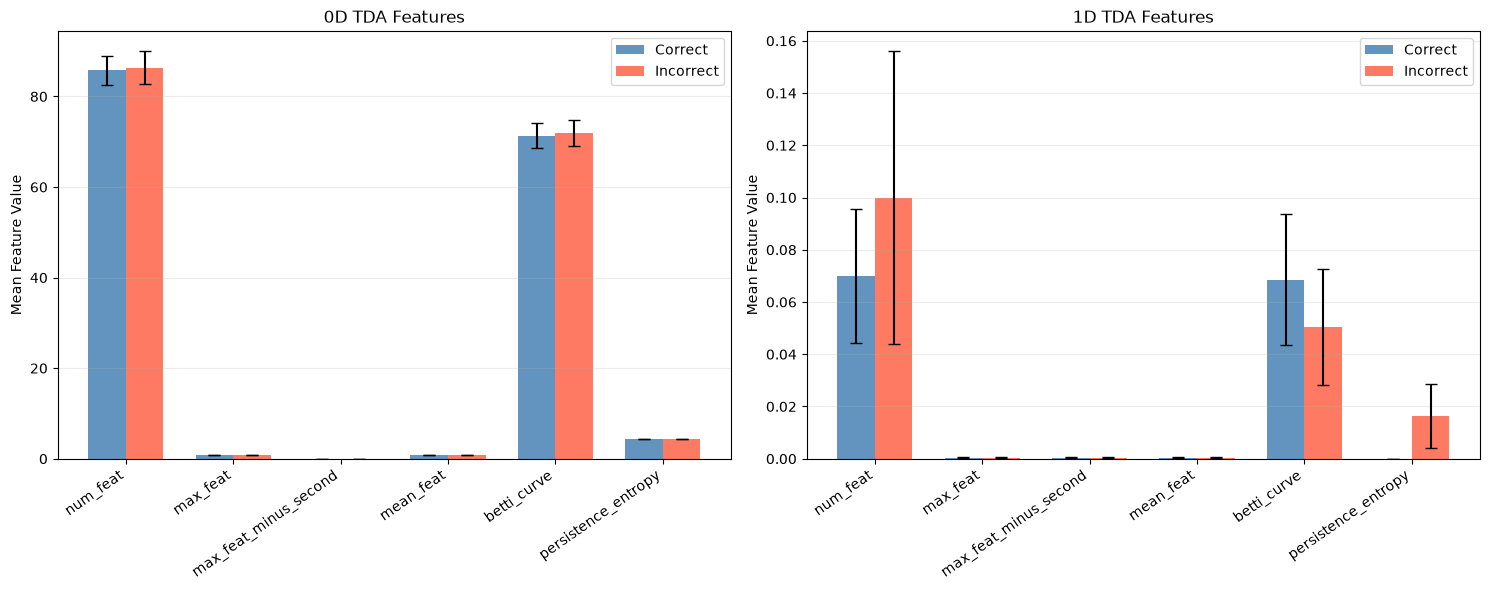

0

In [3]:
# prelim analysis
topo.analyze_feats(models[2], datasets[5], False)

In [4]:
# heatmap labels
linguistic_labels = [['Linguistic Features',["num_tokens", "num_types", "avg_word_length", "char_count",
                        "ttr", "cttr", "herdan_c", "simpson_div", "yules_k",
                        "num_content_words", "lexical_density",
                        "avg_polysemy", "num_long_words", "long_word_ratio", "hapax_legomena", "hapax_ratio",
                        "num_stopwords", "stopword_ratio",
                        "noun_ratio", "verb_ratio", "adj_ratio", "adv_ratio",
                        "entropy", "top_word_freq",
                        "unique_bigram_approx"]]
]

tda_labels = [["Topological Features", ['Num_0dim', 'Max_0dim', 'Max_0dim_Minus_Second', 'Mean_0dim', 'betti_curve_0', 'persistence_entropy_0', 'Num_1dim', 'Max_1dim', 'Max_1dim_Minus_Second', 'Mean_1dim', 'betti_curve_1', 'persistence_entropy_1']],
              ["h0 Features", ["Num_0dim", "Max_0dim", "Mean_0dim", "betti_curve_0", "persistence_entropy_0"]],
              ["h1 Features", ["Num_1dim", "Max_1dim", "Mean_1dim", "betti_curve_1", "persistence_entropy_1"]]
]

print("# features: ", len(linguistic_labels[0][1]))

# features:  25


Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.56640625 0.86889648
Filtration range 1 dim: None None


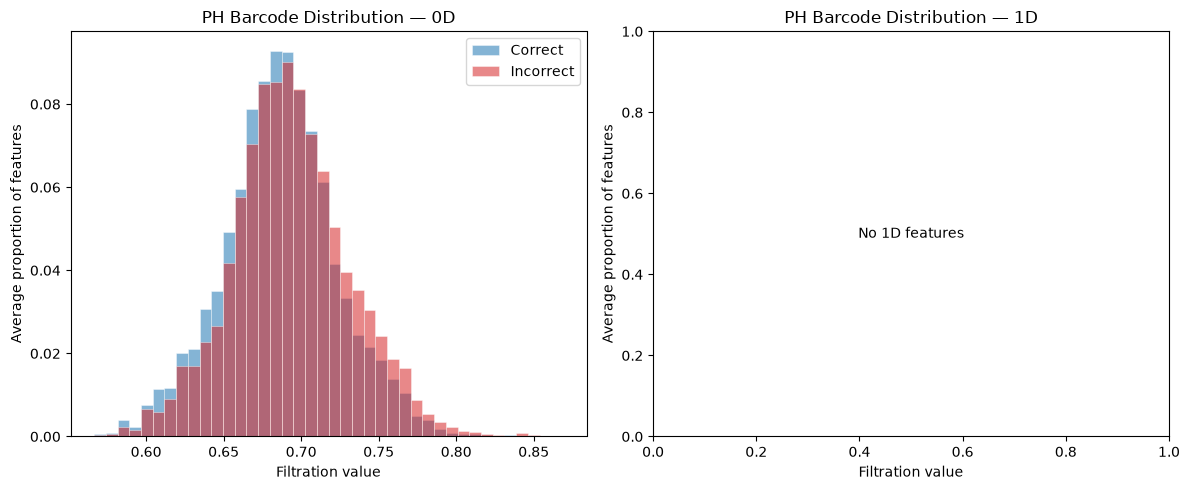

0

In [5]:
topo.plot_barcode(models[0], datasets[0])

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['hellaswag', '~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+-----------------------+-----------------------+-----------------------+--------------------+----------------------+
|       label        |      num_feat      |        max_feat       | max_feat_minus_second |       mean_feat       |    betti_curve     | persistence_entropy  |
+--------------------+--------------------+-----------------------+-----------------------+-----------------------+--------------------+----------------------+
|    correct_0dim    |       151.32       |    0.79206298828125   |   0.015328369140625   |   0.687822082908314   |      129.1614      |  4.893200983525947   |
| correct_0dim_stdv  | 7.3814520484410355 |  0.003144526970758296 |  0.001468780319479728 | 0.0011213959210956052 | 6.054223684721806  | 0.05086026817592554  |
|    correc

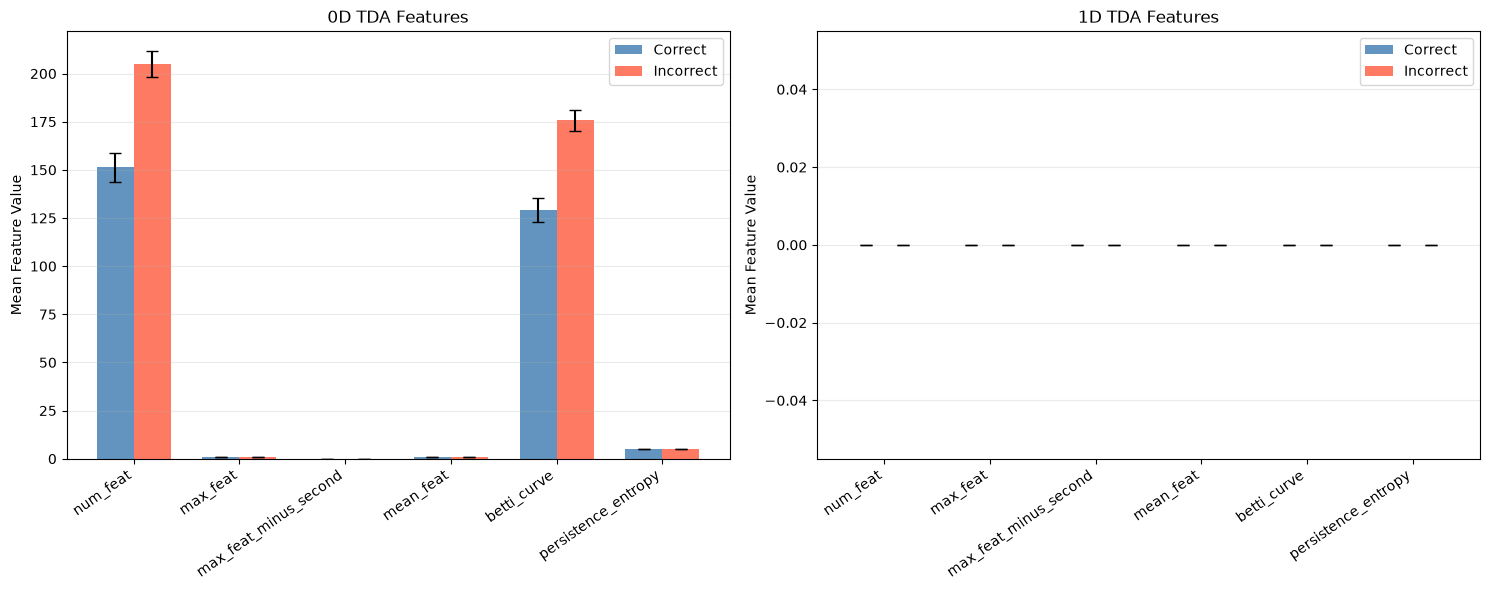

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.56640625 0.88970947
Filtration range 1 dim: None None


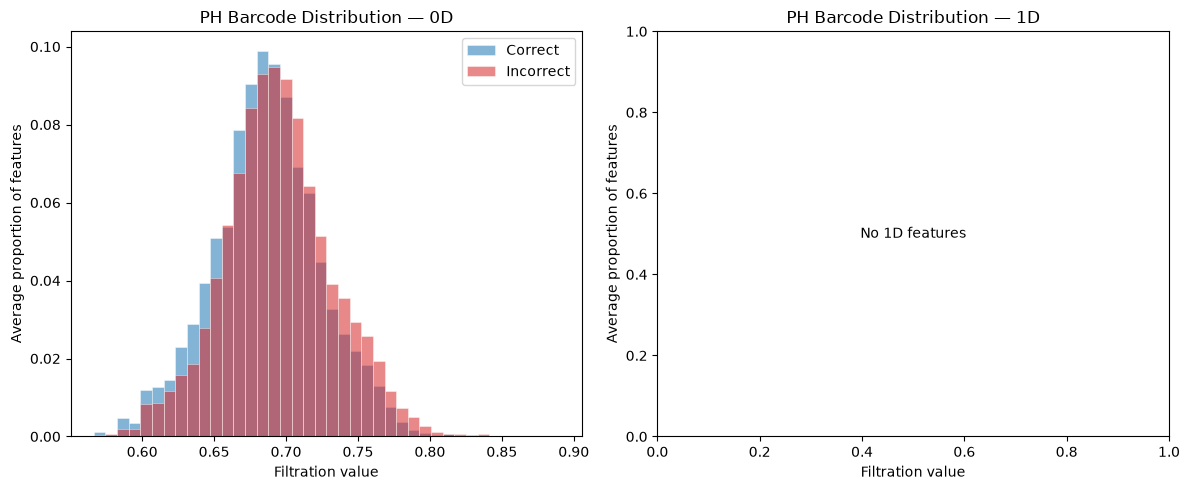

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['mmlu_law', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_law.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+-----------------------+-----------------------+------------------------+---------------------+---------------------+
|       label        |       num_feat      |        max_feat       | max_feat_minus_second |       mean_feat        |     betti_curve     | persistence_entropy |
+--------------------+---------------------+-----------------------+-----------------------+------------------------+---------------------+---------------------+
|    correct_0dim    |        227.37       |   0.791256103515625   |   0.019241943359375   |   0.6799149195613927   |       193.2704      |  5.3457931334581765 |
| correct_0dim_stdv  |  8.345707842594262  | 0.0029906536835891707 | 0.0019685843608890155 | 0.0008568806884616872  |  6.9683630324430705 | 0.04315511733654704 |
|  

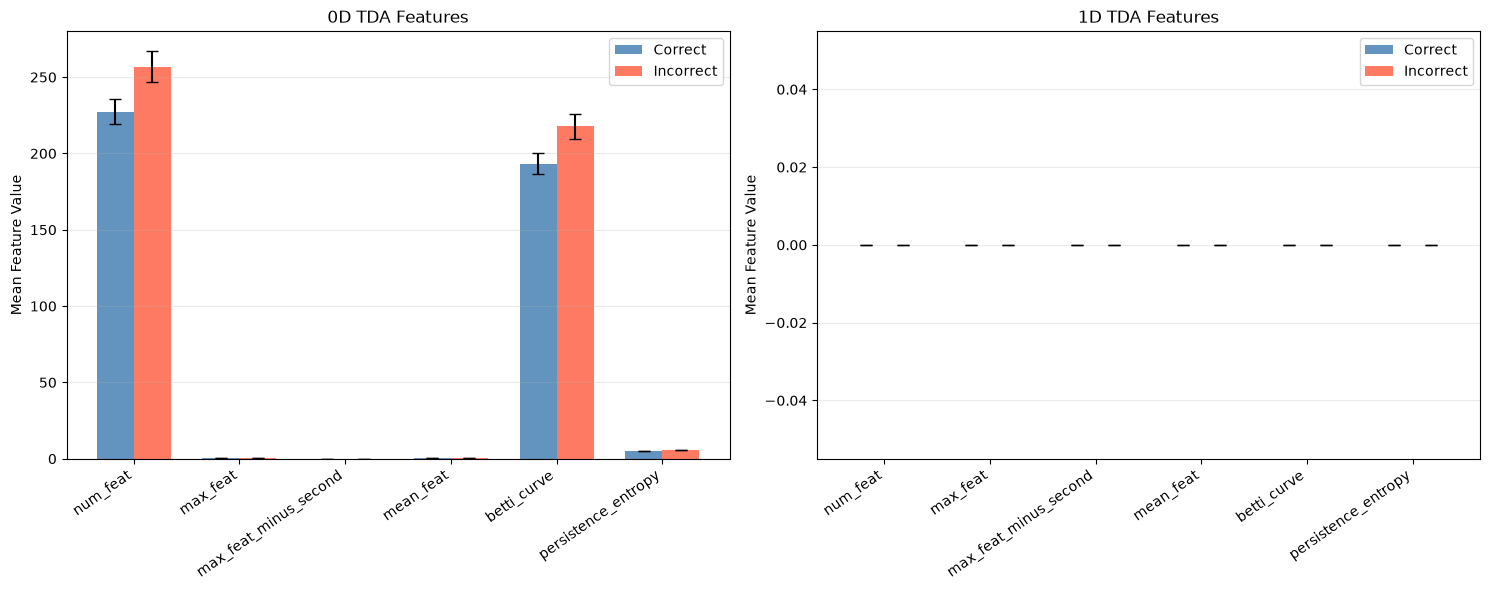

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.56323242 0.87548828
Filtration range 1 dim: None None


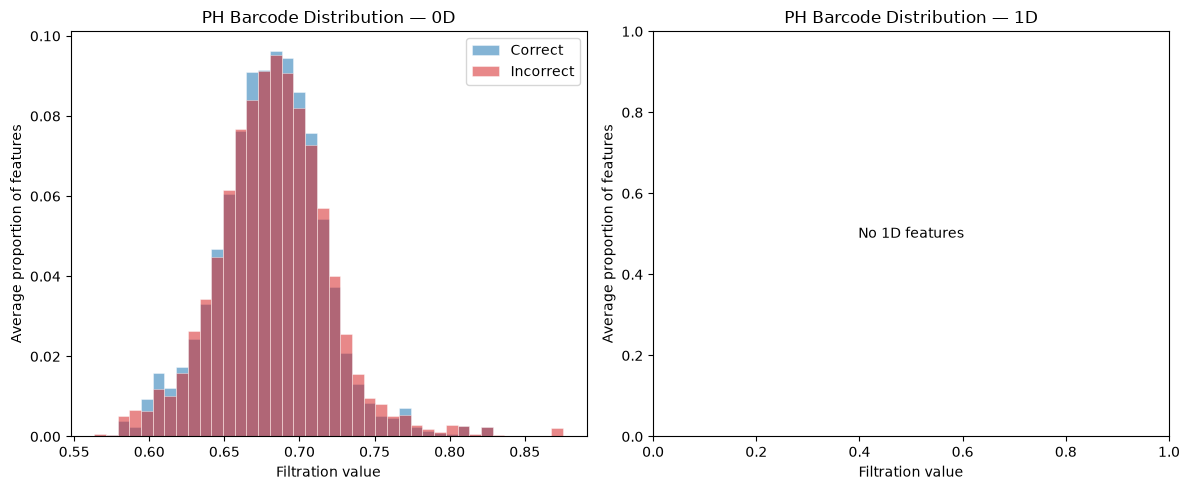

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['mmlu_math', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_math.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+-----------------------+------------------------+------------------------+--------------------+----------------------+
|       label        |      num_feat      |        max_feat       | max_feat_minus_second  |       mean_feat        |    betti_curve     | persistence_entropy  |
+--------------------+--------------------+-----------------------+------------------------+------------------------+--------------------+----------------------+
|    correct_0dim    |       60.44        |   0.766351318359375   |   0.009505615234375    |   0.6888060034658436   | 53.675200000000004 |  4.041286308820969   |
| correct_0dim_stdv  | 2.1289405531362022 | 0.0019429036684607763 | 0.0007999036142506508  | 0.0011868411292509232  | 1.833843127357838  | 0.03424516519317267  |
|

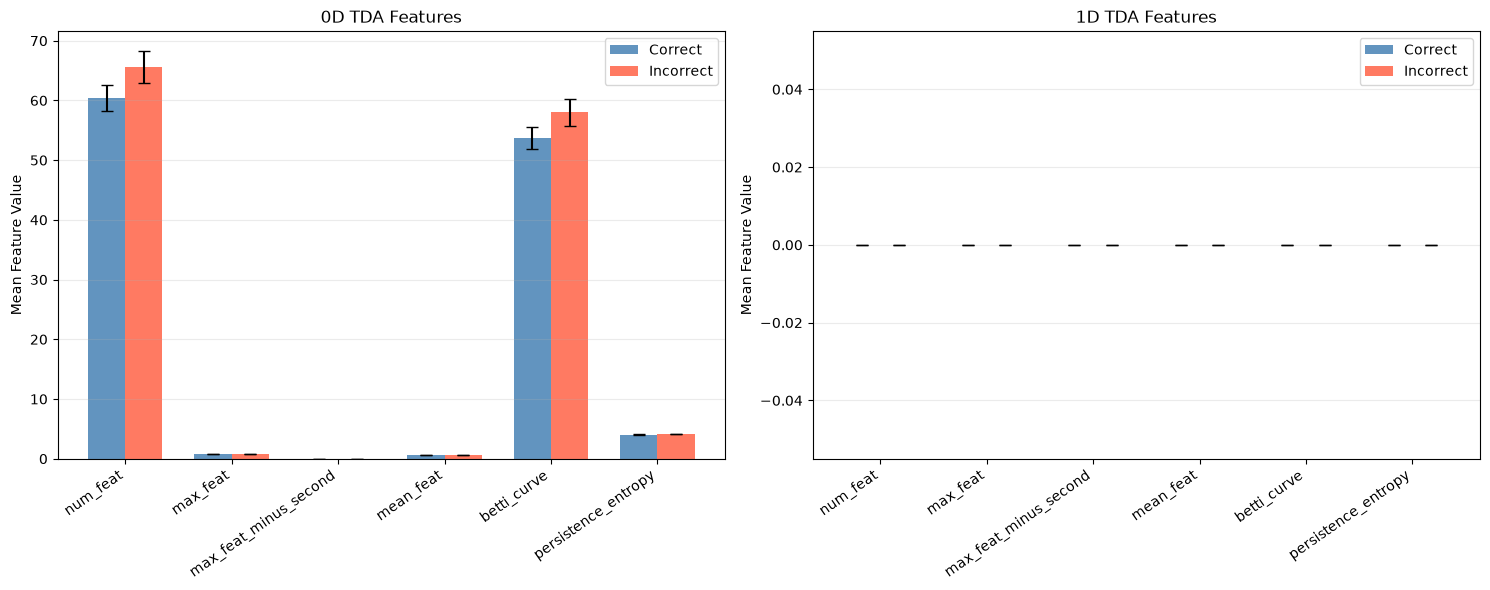

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.55371094 0.89538574
Filtration range 1 dim: None None


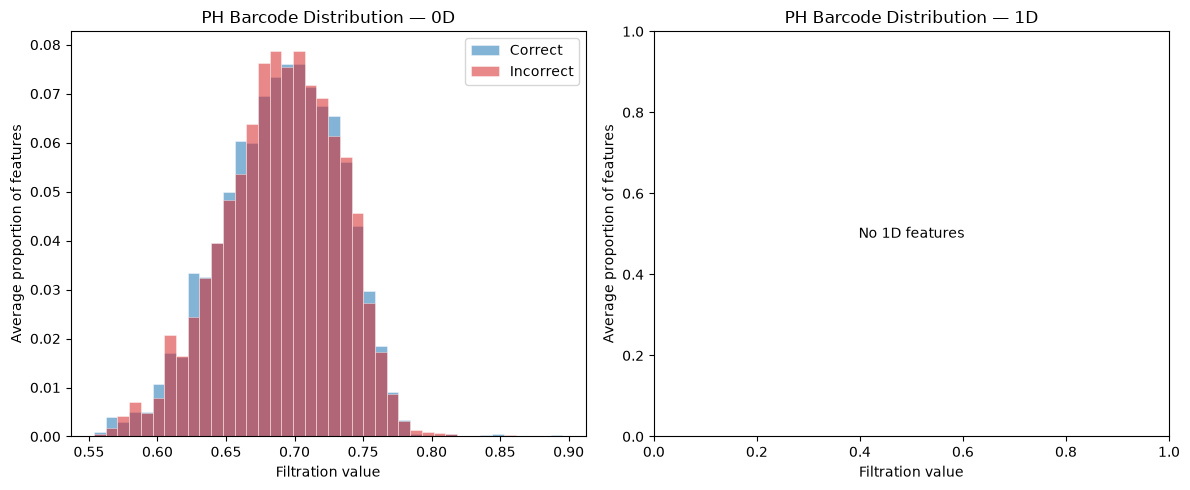

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['mmlu_misc', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_misc.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+-----------------------+------------------------+-----------------------+---------------------+-----------------------+
|       label        |       num_feat      |        max_feat       | max_feat_minus_second  |       mean_feat       |     betti_curve     |  persistence_entropy  |
+--------------------+---------------------+-----------------------+------------------------+-----------------------+---------------------+-----------------------+
|    correct_0dim    |        48.03        |    0.76301513671875   |    0.01093017578125    |   0.6670374430464302  |  41.53239999999999  |   3.7828789482739977  |
| correct_0dim_stdv  |  2.7361941791215374 | 0.0018286164091025632 | 0.0012324631555263167  | 0.0006828841967865563 |  2.3355493335172626 |  0.037773186120

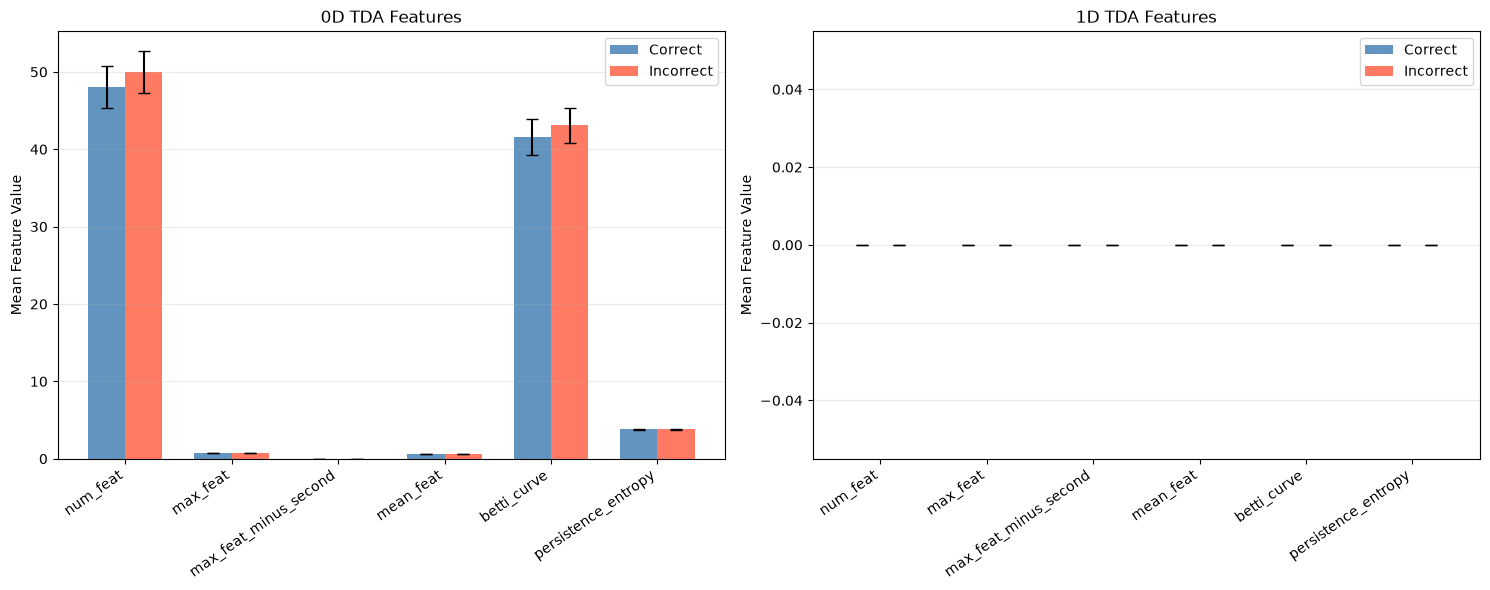

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.5546875 0.85302734
Filtration range 1 dim: None None


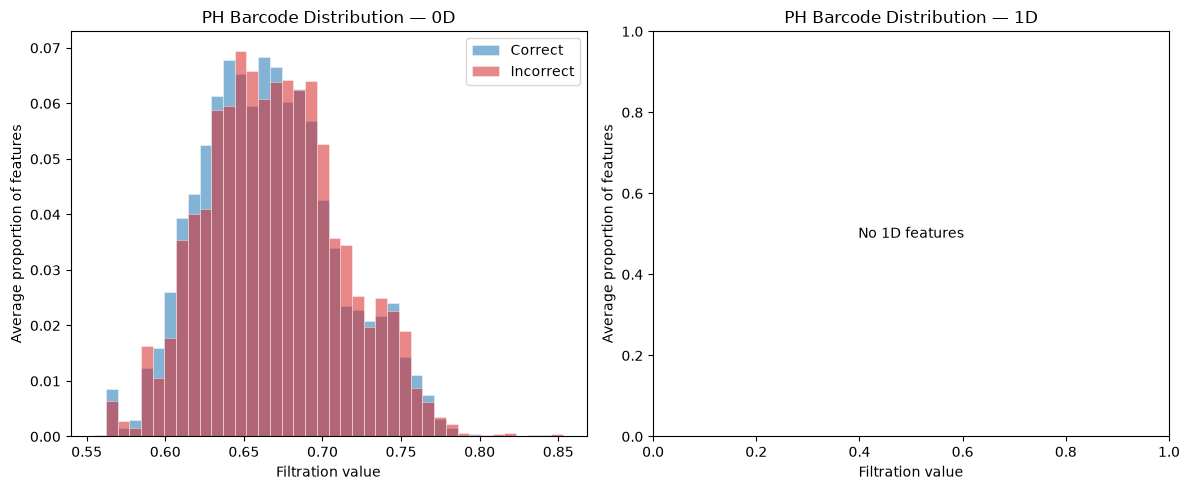

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['mmlu_moral', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_moral.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+-----------------------+------------------------+-------------------------+---------------------+------------------------+
|       label        |       num_feat      |        max_feat       | max_feat_minus_second  |        mean_feat        |     betti_curve     |  persistence_entropy   |
+--------------------+---------------------+-----------------------+------------------------+-------------------------+---------------------+------------------------+
|    correct_0dim    |        102.92       |   0.791312255859375   |    0.01027587890625    |    0.6730875793734115   |       86.8258       |   4.629816272636728    |
| correct_0dim_stdv  |  0.667829289261829  |  0.001441949545080284 | 0.0010187642355271368  |  0.00019014082594120968 |  0.5649396352842943 |

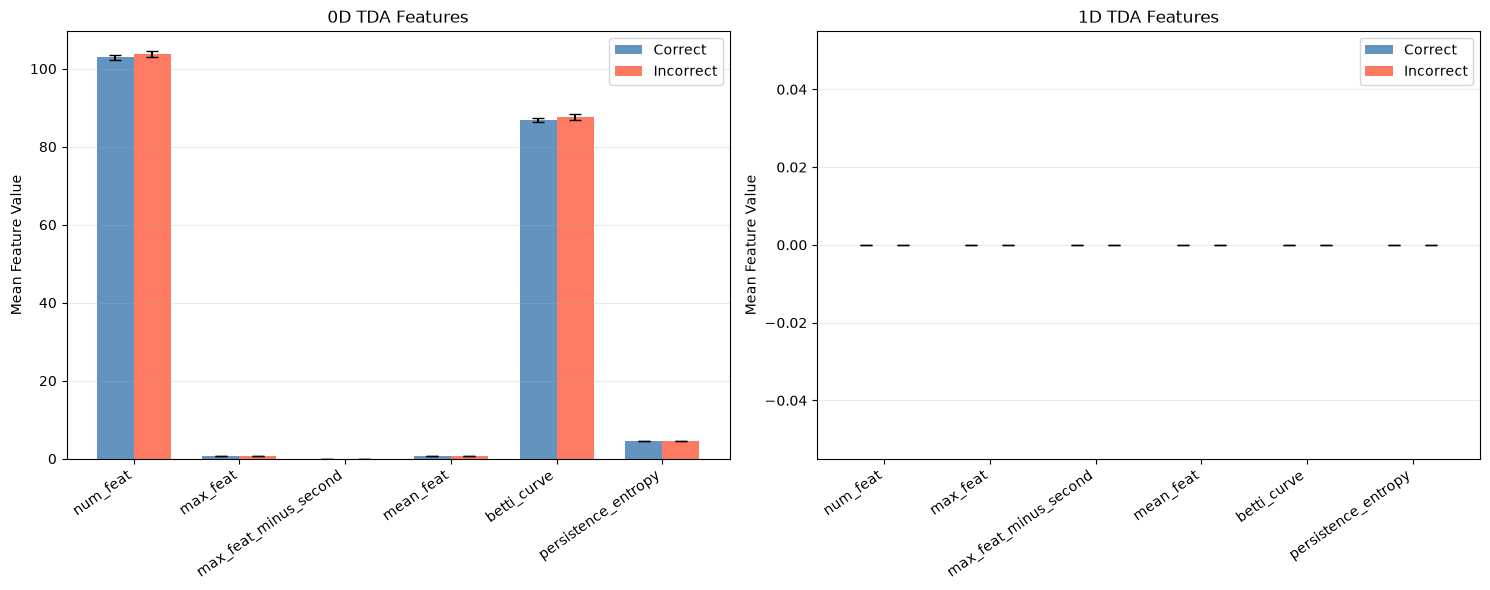

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.58544922 0.85534668
Filtration range 1 dim: None None


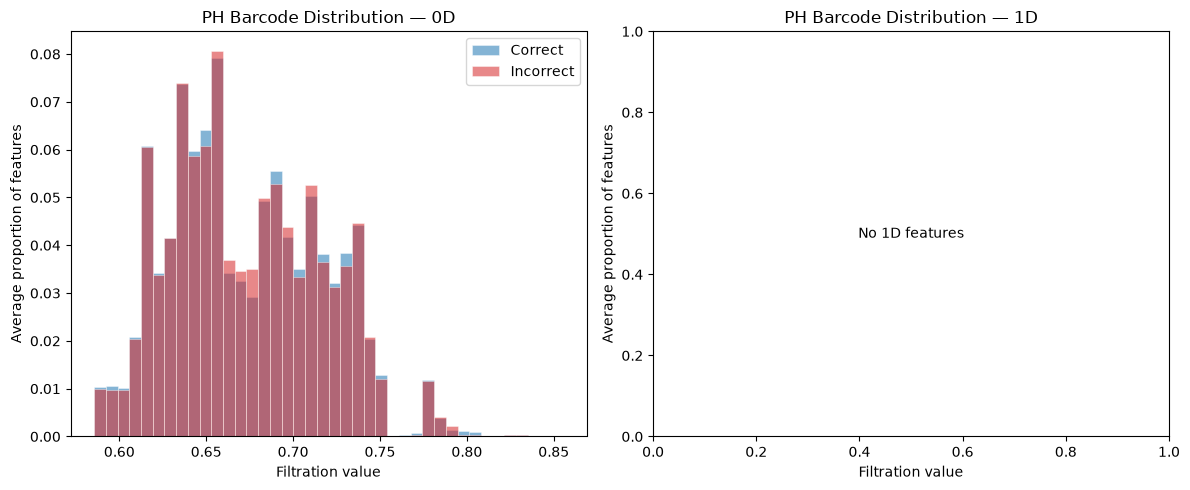

model:  ['Llama 3.1 8B', 'meta-llama/Llama-3.1-8B', 'llama']
dataset:  ['mmlu_psych', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_psych.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+------------------------+-----------------------+------------------------+---------------------+----------------------+
|       label        |       num_feat      |        max_feat        | max_feat_minus_second |       mean_feat        |     betti_curve     | persistence_entropy  |
+--------------------+---------------------+------------------------+-----------------------+------------------------+---------------------+----------------------+
|    correct_0dim    |         77.0        |    0.77361572265625    |   0.014744873046875   |   0.6696498517168499   |  65.94319999999999  |  4.272923741151947   |
| correct_0dim_stdv  |  2.911488910637936  |  0.002782455319537624  | 0.0015692510076245596 | 0.0008301698637308428  |  2.4547008000523762 | 0.0375936330

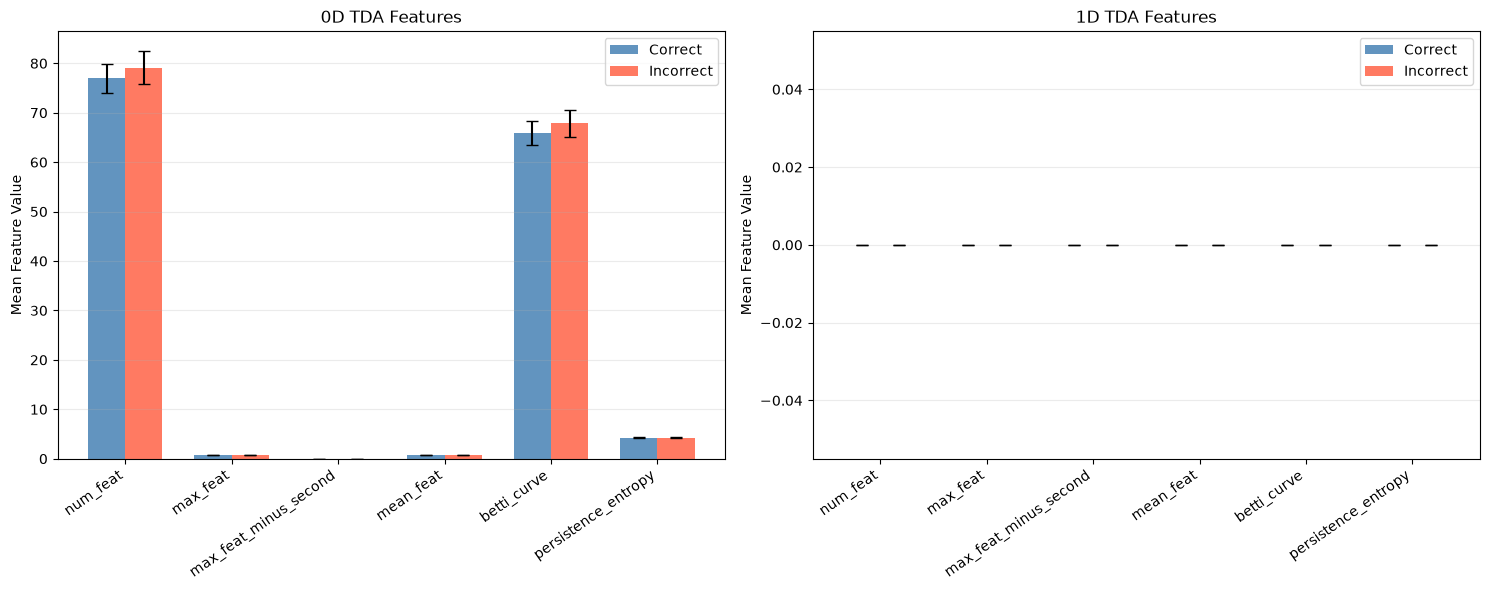

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.55249023 0.87536621
Filtration range 1 dim: None None


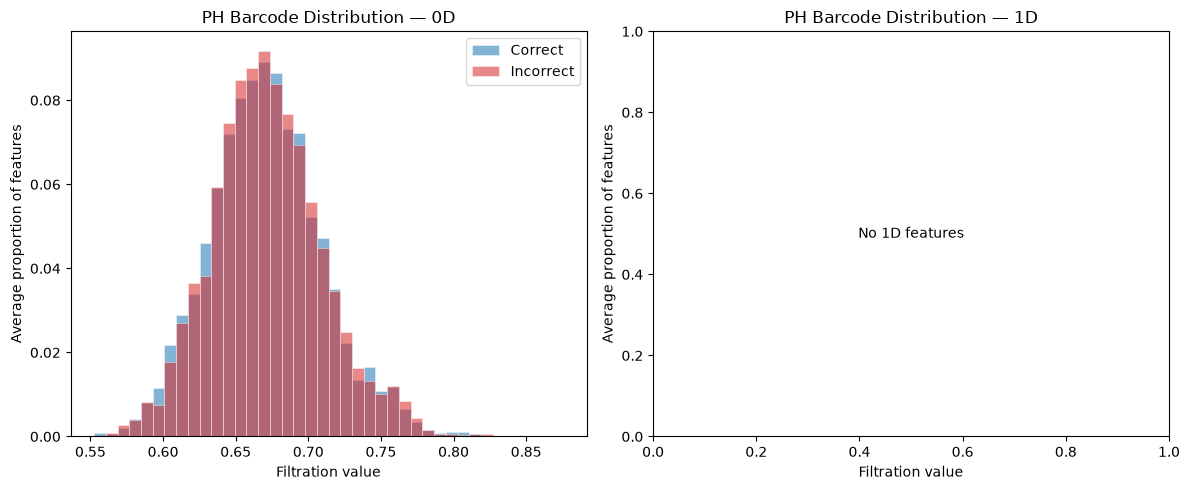

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['hellaswag', '~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+-----------------------+-----------------------+------------------------+--------------------+----------------------+
|       label        |       num_feat      |        max_feat       | max_feat_minus_second |       mean_feat        |    betti_curve     | persistence_entropy  |
+--------------------+---------------------+-----------------------+-----------------------+------------------------+--------------------+----------------------+
|    correct_0dim    |        181.2        |    0.83770751953125   |   0.0207867431640625  |   0.7184499216670642   | 153.22979999999998 |  5.098993470134619   |
| correct_0dim_stdv  |  7.017942373054595  | 0.0031432585315865507 | 0.0018466454241670722 | 0.0007558356338161823  | 5.782594297344123  | 0.04834552482160021  |
|    correct_1d

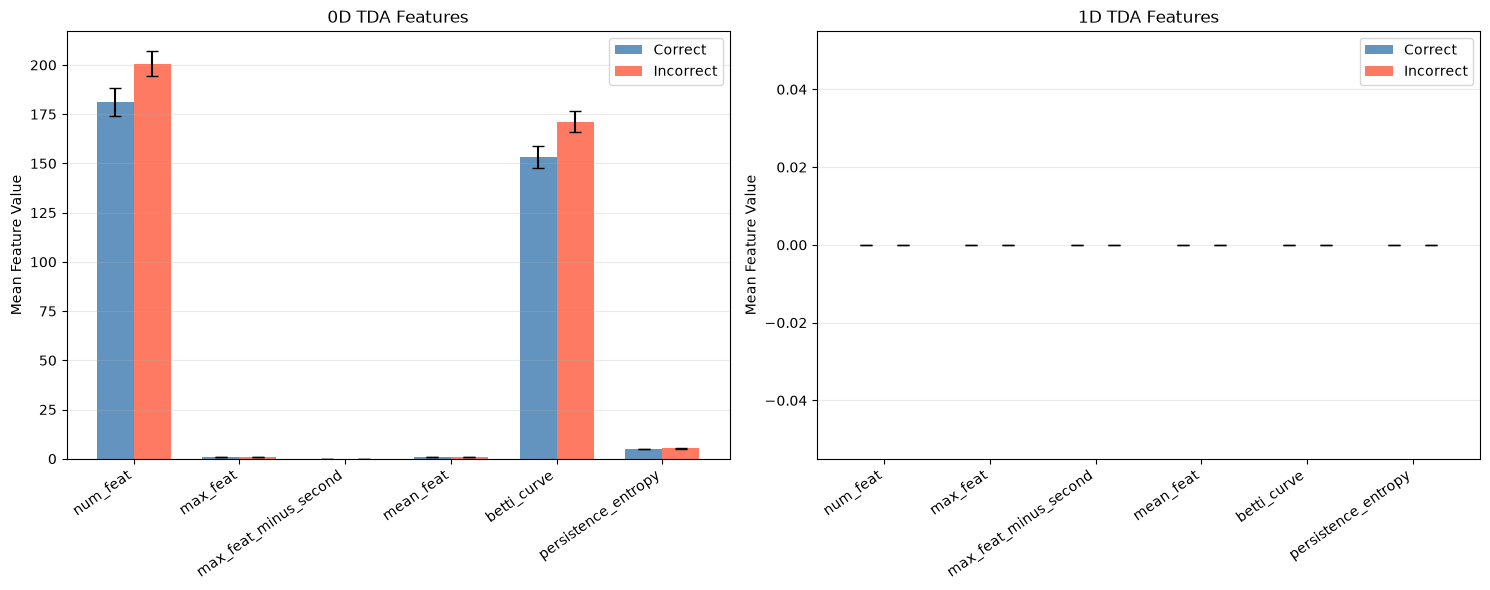

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.58129883 0.90576172
Filtration range 1 dim: None None


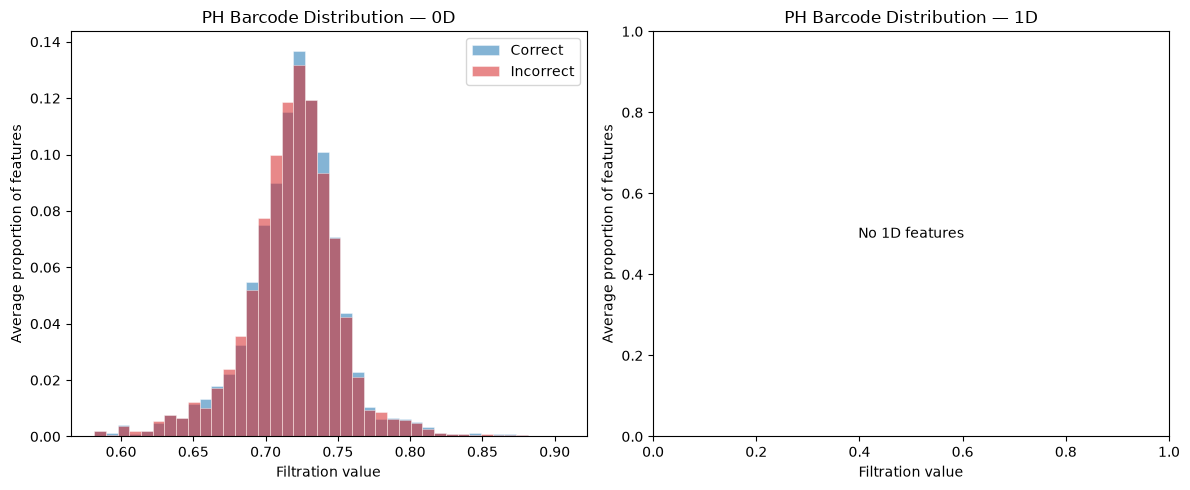

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['mmlu_law', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_law.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+-----------------------+------------------------+-------------------------+--------------------+----------------------+
|       label        |      num_feat      |        max_feat       | max_feat_minus_second  |        mean_feat        |    betti_curve     | persistence_entropy  |
+--------------------+--------------------+-----------------------+------------------------+-------------------------+--------------------+----------------------+
|    correct_0dim    |       247.98       |   0.8442596435546875  |   0.0214569091796875   |    0.7176576563086796   | 208.97020000000003 |  5.436960823390772   |
| correct_0dim_stdv  | 8.503439351702392  | 0.0027149070773664517 | 0.0017417925622309643  |  0.0007014871009203438  |  7.09799474596434  | 0.04281081103803416  |
|    correct

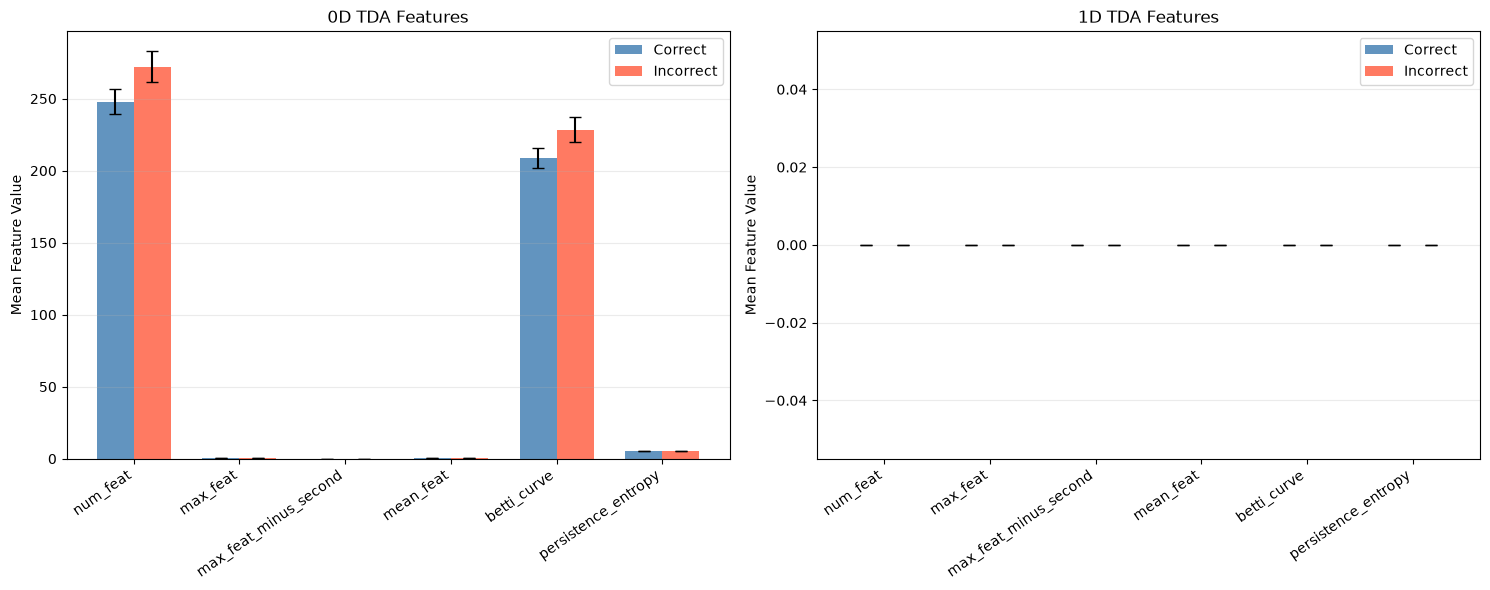

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.56567383 0.91082764
Filtration range 1 dim: None None


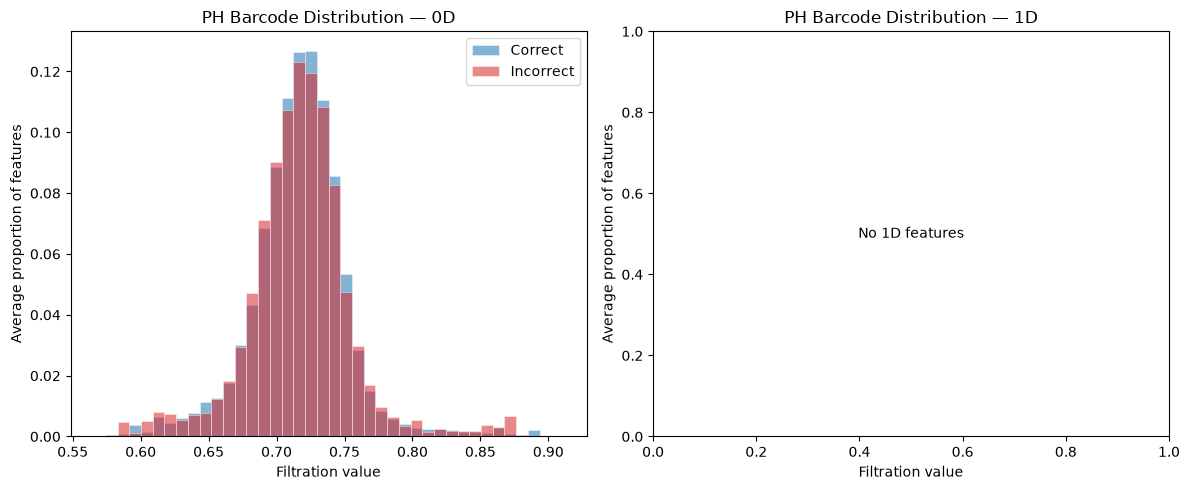

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['mmlu_math', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_math.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+-----------------------+-----------------------+------------------------+--------------------+-----------------------+
|       label        |      num_feat      |        max_feat       | max_feat_minus_second |       mean_feat        |    betti_curve     |  persistence_entropy  |
+--------------------+--------------------+-----------------------+-----------------------+------------------------+--------------------+-----------------------+
|    correct_0dim    |       68.82        |    0.8472998046875    |   0.0173321533203125  |   0.7415801216510916   | 59.63099999999999  |   4.168174961288568   |
| correct_0dim_stdv  | 2.5993153721779136 | 0.0027437684134339027 | 0.0017366356995135164 | 0.0011859330237092725  | 2.2224834298503997 |  0.034459190333433684 |
|    correct_1d

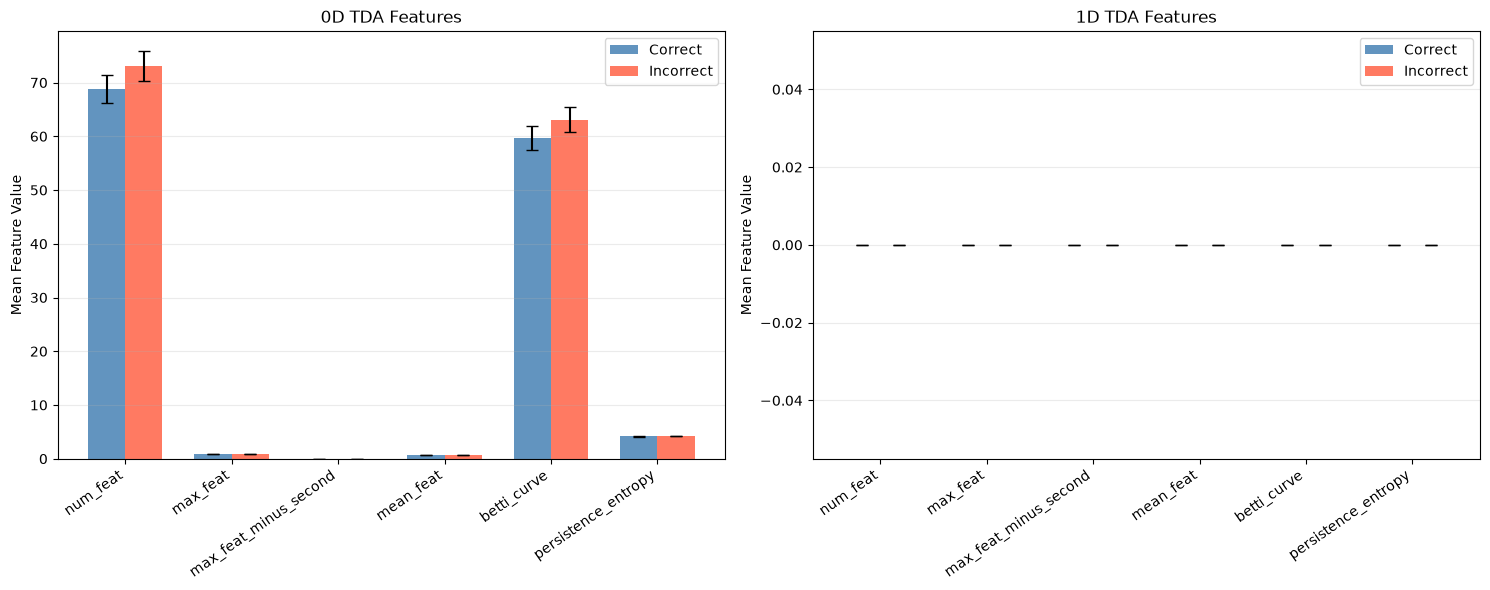

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.55859375 0.91229248
Filtration range 1 dim: None None


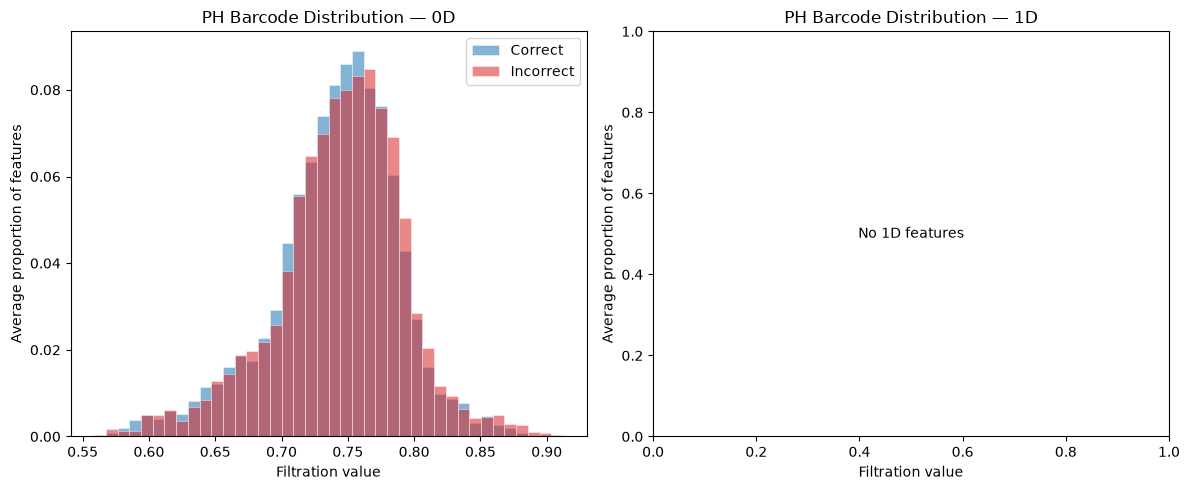

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['mmlu_misc', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_misc.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+-----------------------+-----------------------+-----------------------+--------------------+-----------------------+
|       label        |      num_feat      |        max_feat       | max_feat_minus_second |       mean_feat       |    betti_curve     |  persistence_entropy  |
+--------------------+--------------------+-----------------------+-----------------------+-----------------------+--------------------+-----------------------+
|    correct_0dim    |        45.4        |   0.817264404296875   |   0.013392333984375   |   0.700520229749278   |      38.6682       |   3.7260242452458687  |
| correct_0dim_stdv  | 2.441600733415302  | 0.0018137560914541617 | 0.0010854150479873252 | 0.0012746232410281223 | 2.1227483442295494 |  0.03802311599684395  |
|    correct_1dim   

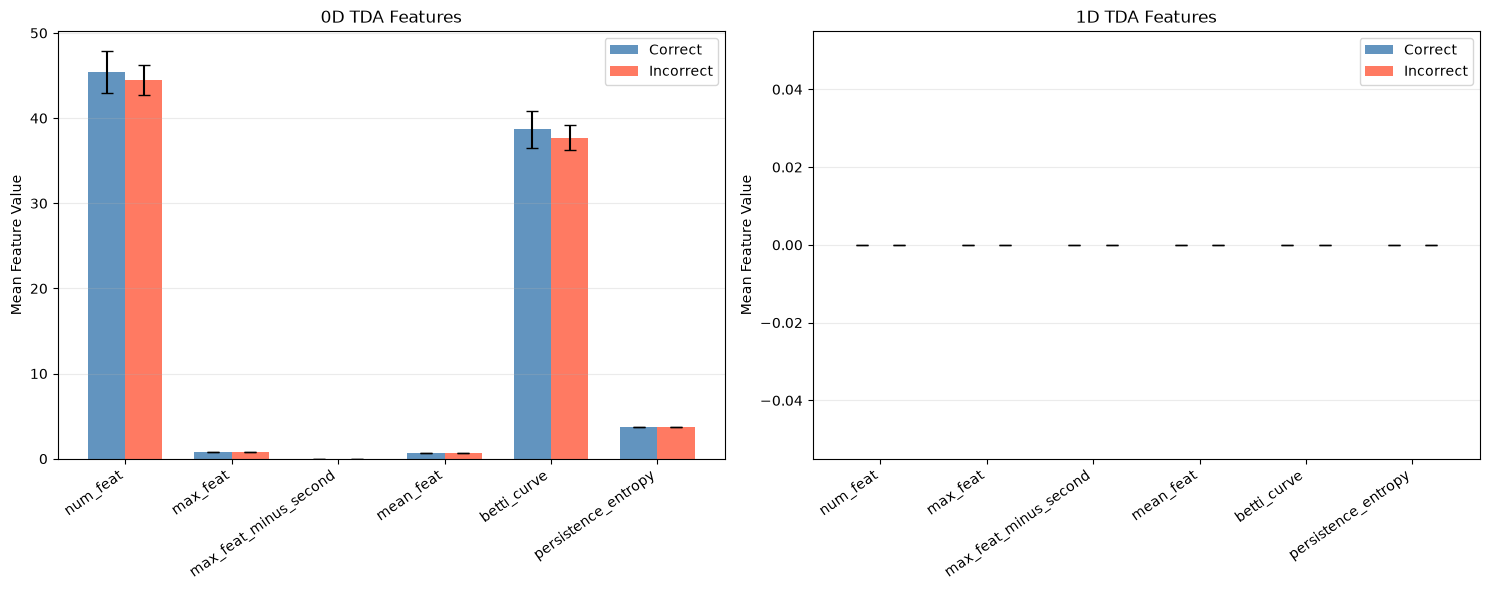

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.54077148 0.88653564
Filtration range 1 dim: None None


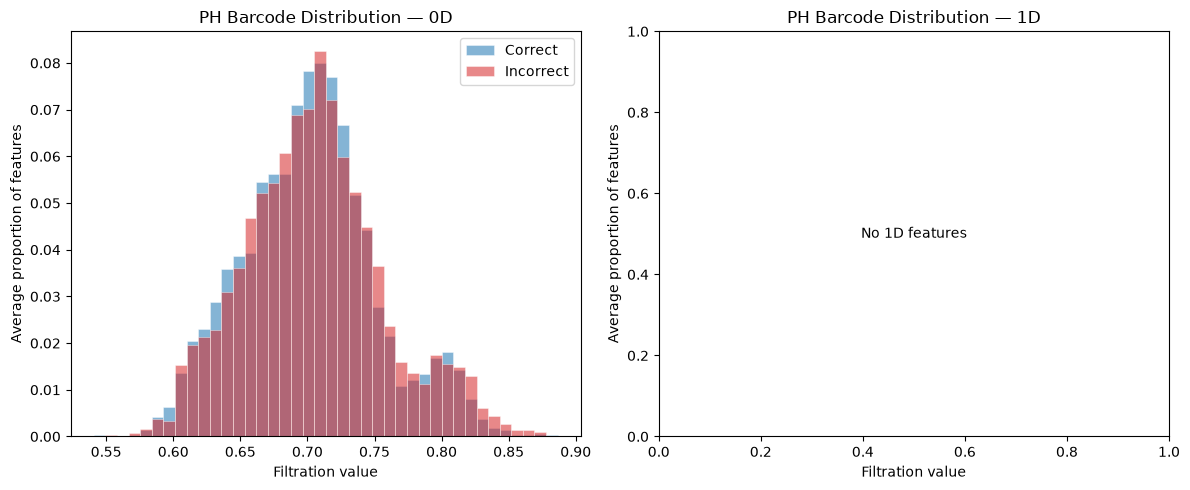

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['mmlu_moral', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_moral.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+-------------------------+-----------------------+-------------------------+---------------------+-----------------------+
|       label        |       num_feat      |         max_feat        | max_feat_minus_second |        mean_feat        |     betti_curve     |  persistence_entropy  |
+--------------------+---------------------+-------------------------+-----------------------+-------------------------+---------------------+-----------------------+
|    correct_0dim    |        103.96       |    0.865067138671875    |    0.0204052734375    |    0.7173437442377394   |  85.50340000000001  |   4.6400570120733615  |
| correct_0dim_stdv  |  0.6797087908833019 |  0.0001741496269045402  | 0.0011414053509232979 |  0.0001606010146520391  |  0.559492992346507  | 0.0063302847

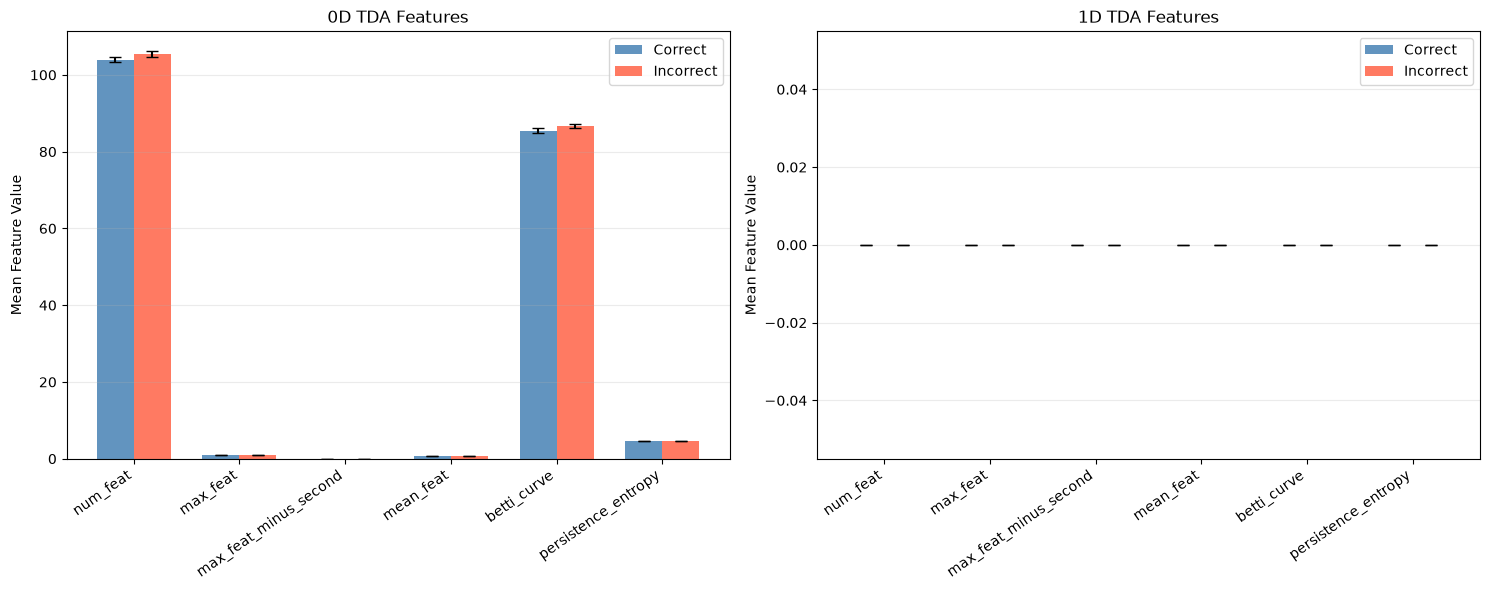

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.6015625 0.87927246
Filtration range 1 dim: None None


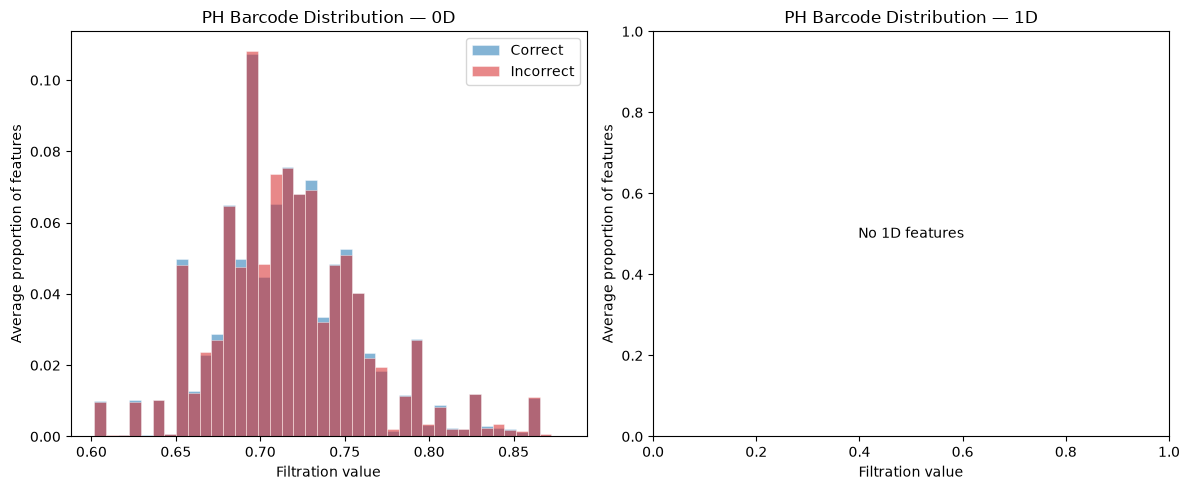

model:  ['Qwen 3 8B', 'Qwen/Qwen3-8B', 'qwen']
dataset:  ['mmlu_psych', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_psych.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+----------------------+------------------------+------------------------+--------------------+-----------------------+
|       label        |       num_feat      |       max_feat       | max_feat_minus_second  |       mean_feat        |    betti_curve     |  persistence_entropy  |
+--------------------+---------------------+----------------------+------------------------+------------------------+--------------------+-----------------------+
|    correct_0dim    |        73.35        |  0.8189251708984375  |   0.0158782958984375   |   0.7066039680565158   |      62.8478       |   4.227923489448414   |
| correct_0dim_stdv  |  2.7692530809340314 | 0.00195338003920952  | 0.0012281101034295721  | 0.0009079433896554872  | 2.375715384357888  |  0.036143379032215275 |
|    cor

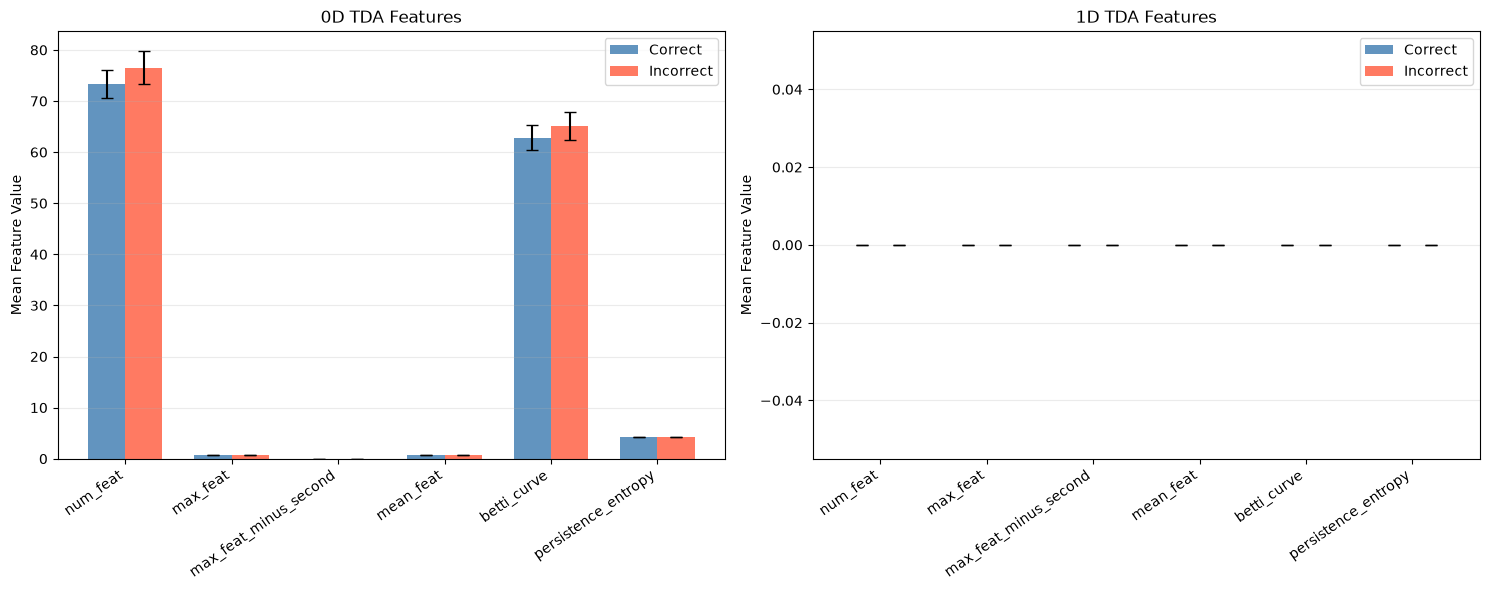

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 0
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.55566406 0.89886475
Filtration range 1 dim: None None


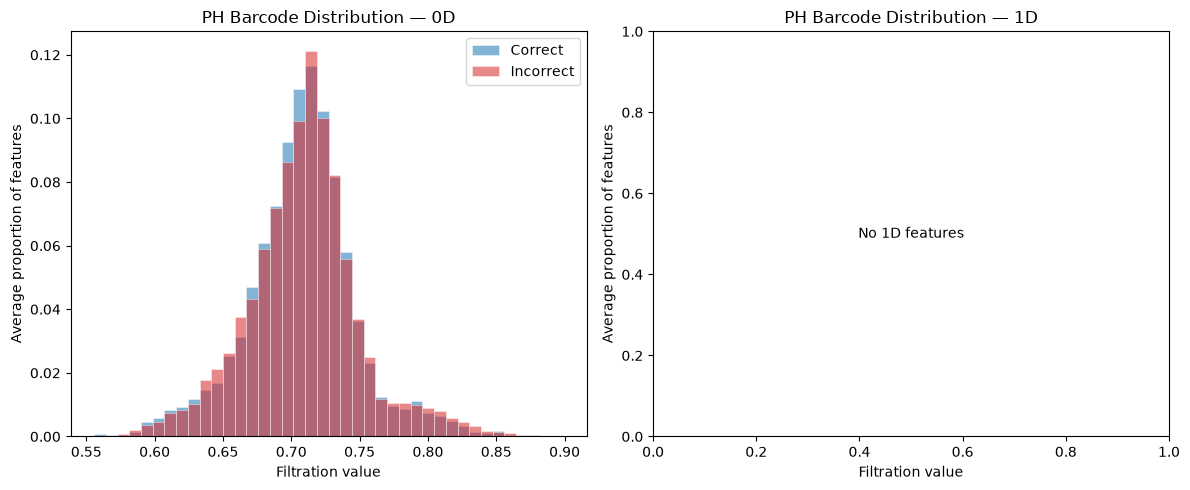

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['hellaswag', '~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+---------------------+------------------------+------------------------+------------------------+----------------------+-----------------------+
|       label        |       num_feat      |        max_feat        | max_feat_minus_second  |       mean_feat        |     betti_curve      |  persistence_entropy  |
+--------------------+---------------------+------------------------+------------------------+------------------------+----------------------+-----------------------+
|    correct_0dim    |        146.01       |   0.8998187255859375   |    0.00832275390625    |   0.7758087080898685   |  124.58459999999997  |   4.854690354594824   |
| correct_0dim_stdv  |   7.4792844550529   |  0.001715107396357448  | 0.0007826430347178589  | 0.0011987673340844499  |  6.3195899167236

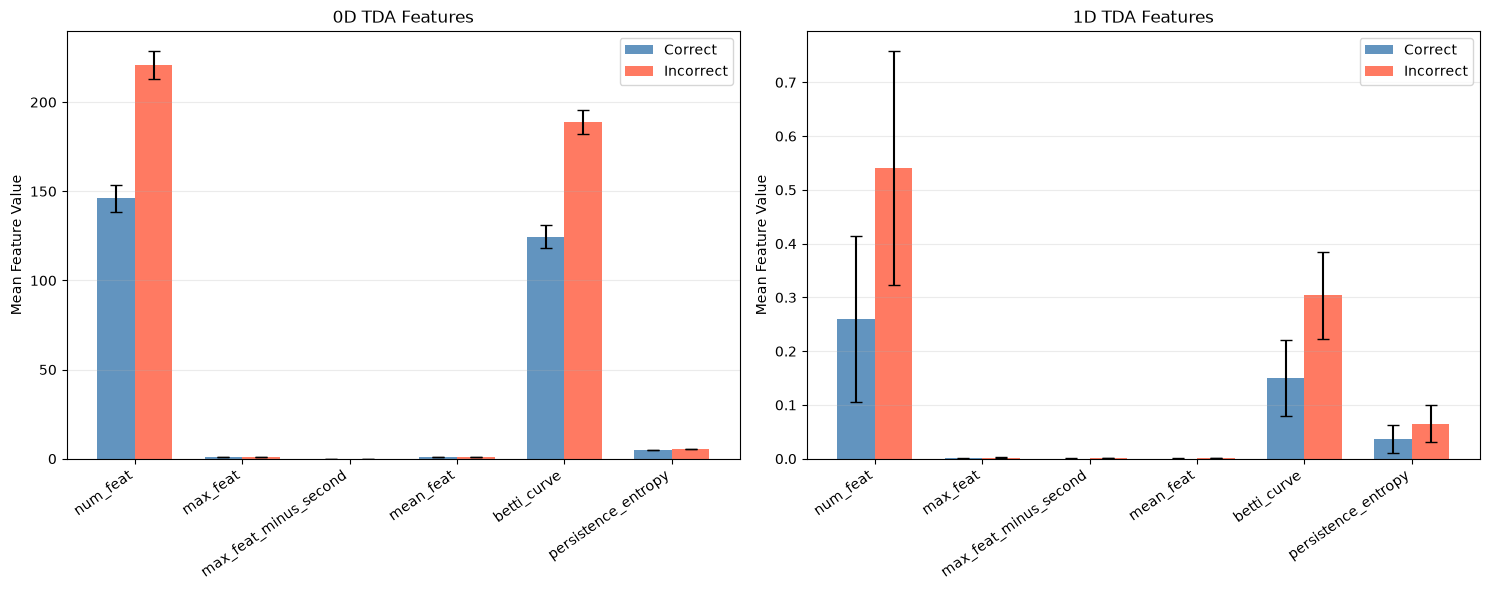

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 9
Incorrect samples 1 dim: 15
Filtration range 0 dim: 0.52392578 0.94354248
Filtration range 1 dim: 0.90655518 0.98143005


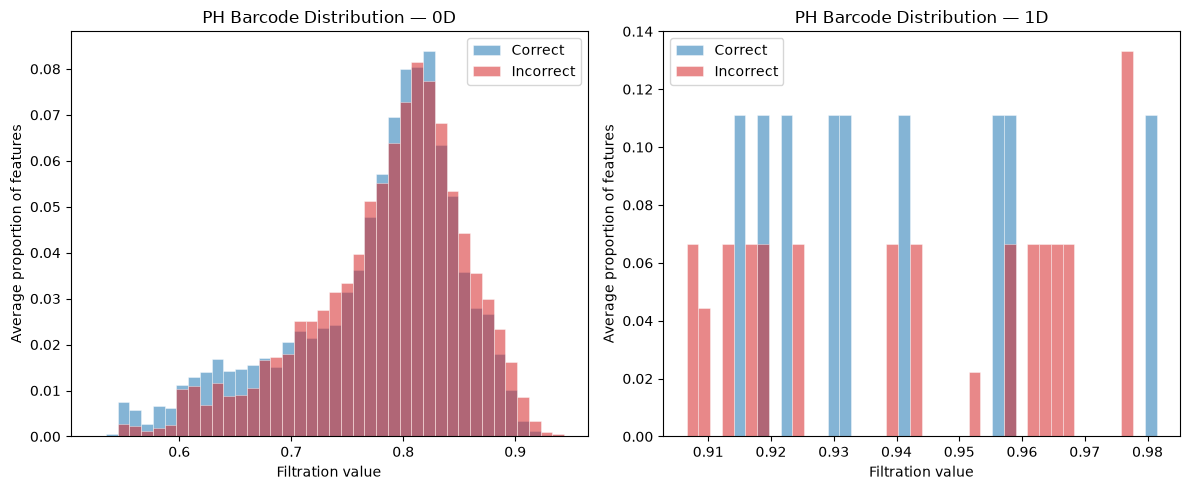

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['mmlu_law', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_law.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+----------------------+-----------------------+------------------------+------------------------+---------------------+----------------------+
|       label        |       num_feat       |        max_feat       | max_feat_minus_second  |       mean_feat        |     betti_curve     | persistence_entropy  |
+--------------------+----------------------+-----------------------+------------------------+------------------------+---------------------+----------------------+
|    correct_0dim    |        267.14        |   0.9158709716796875  |   0.0112213134765625   |   0.7574660206317795   |       219.0106      |  5.497215286502748   |
| correct_0dim_stdv  |  9.796443592993688   | 0.0015236440376291184 | 0.0008301662346173937  |  0.001292388617709145  |  8.056044172764654  | 0.04

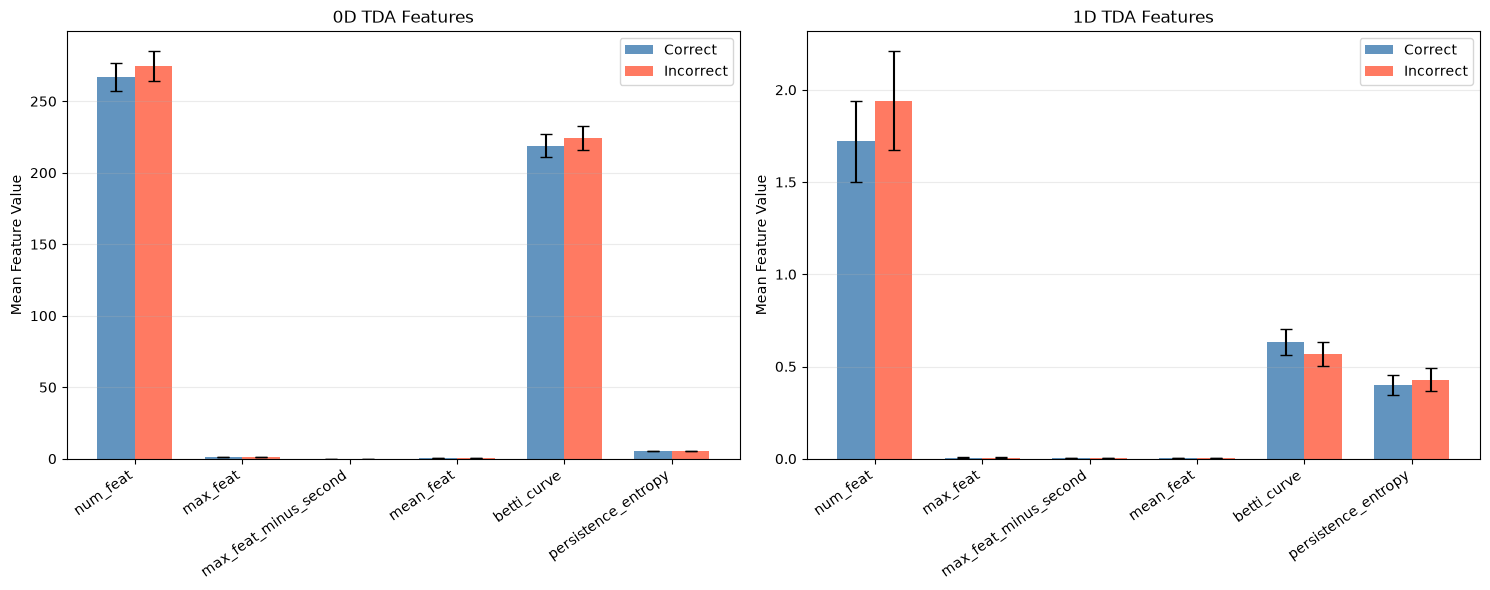

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 59
Incorrect samples 1 dim: 56
Filtration range 0 dim: 0.54052734 0.95956421
Filtration range 1 dim: 0.90716553 0.99060059


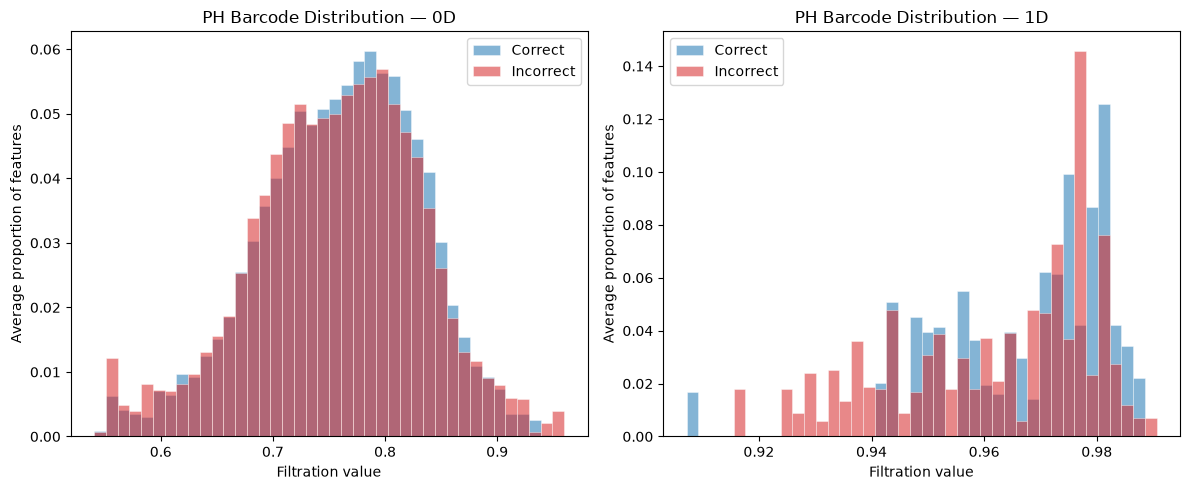

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['mmlu_math', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_math.csv']
Sampling 97 correct and 100 incorrect examples
+--------------------+-----------------------+------------------------+------------------------+------------------------+------------------------+----------------------+
|       label        |        num_feat       |        max_feat        | max_feat_minus_second  |       mean_feat        |      betti_curve       | persistence_entropy  |
+--------------------+-----------------------+------------------------+------------------------+------------------------+------------------------+----------------------+
|    correct_0dim    |   69.96907216494846   |   0.8761514879993557   |  0.006555930855347938  |   0.7644639230788274   |   60.402474226804124   |  4.178141952255661   |
| correct_0dim_stdv  |    2.66094694828085   |  0.001474100436041099  | 0.0006321332089139617  | 0.0016740447488013492  |   2

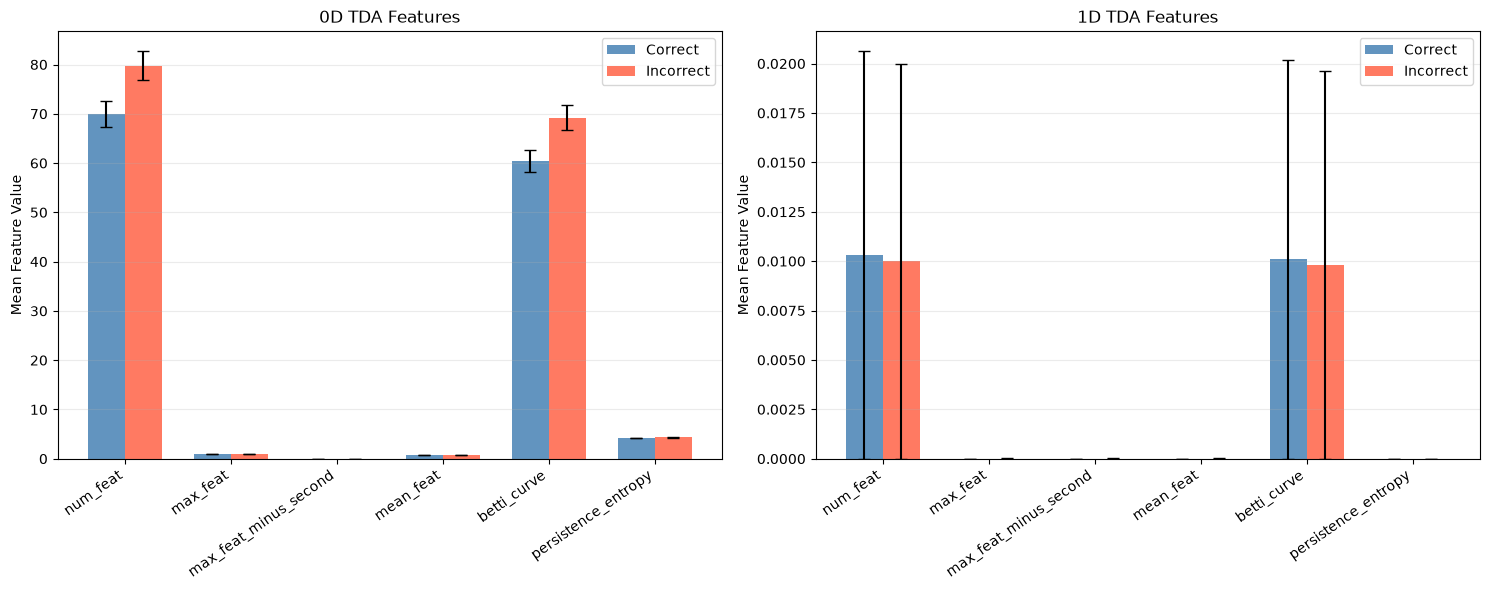

Sampling 97 correct and 100 incorrect examples
Correct samples 0 dim: 97
Incorrect samples 0 dim: 100
Correct samples 1 dim: 1
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.53417969 0.91790771
Filtration range 1 dim: 0.9609375 0.9609375


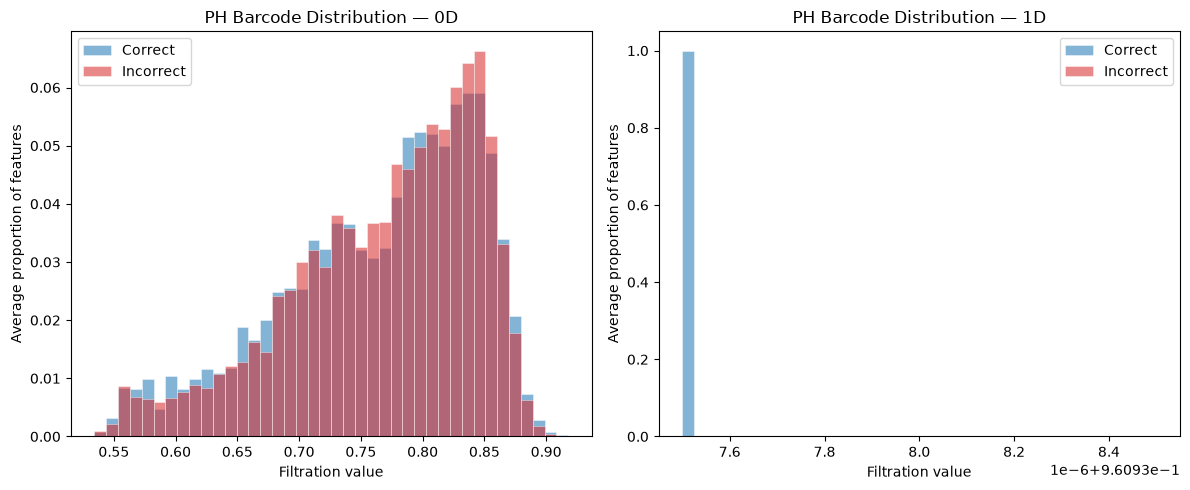

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['mmlu_misc', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_misc.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+--------------------+-----------------------+------------------------+-----------------------+--------------------+----------------------+
|       label        |      num_feat      |        max_feat       | max_feat_minus_second  |       mean_feat       |    betti_curve     | persistence_entropy  |
+--------------------+--------------------+-----------------------+------------------------+-----------------------+--------------------+----------------------+
|    correct_0dim    |        51.0        |   0.8624163818359375  |   0.0063043212890625   |   0.7374283959251129  |      43.1224       |  3.8509699099763783  |
| correct_0dim_stdv  | 2.5088127499160664 | 0.0016570340238488024 | 0.0006253636481096294  | 0.0013103168794285631 | 2.076946015162404  | 0.03503307789805318  |

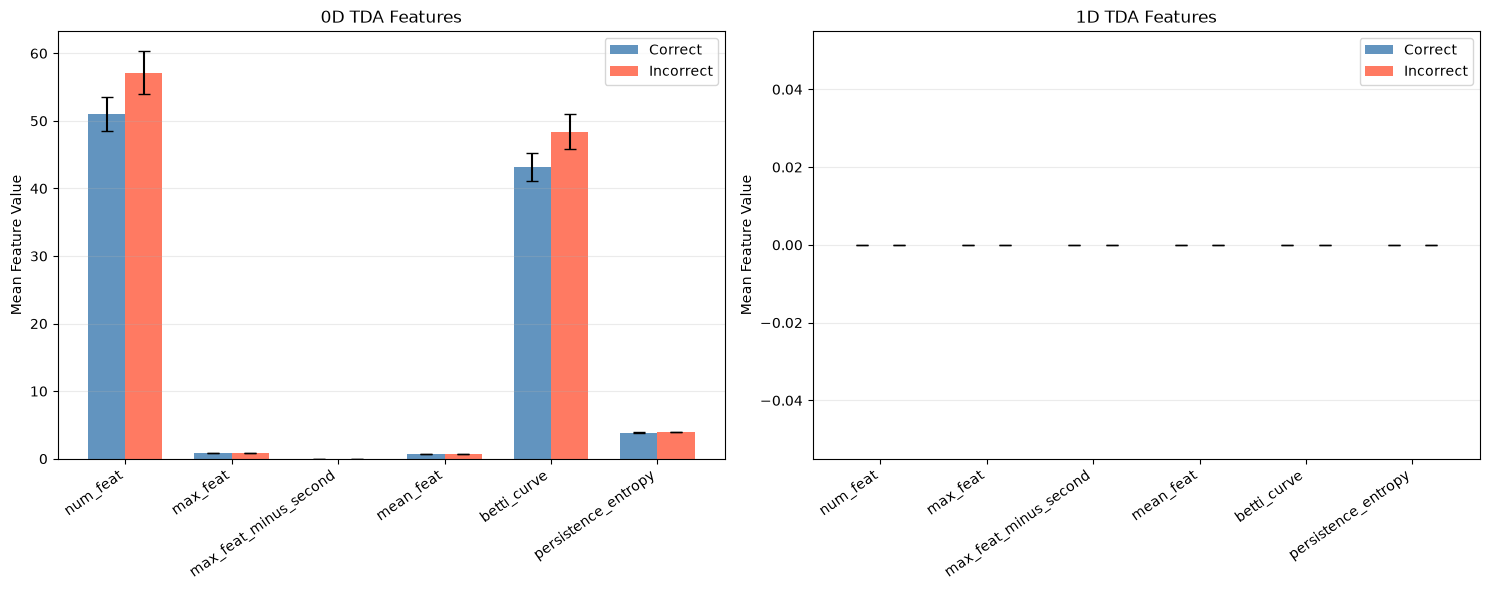

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 1
Incorrect samples 1 dim: 0
Filtration range 0 dim: 0.53320312 0.93115234
Filtration range 1 dim: 0.92419434 0.92419434


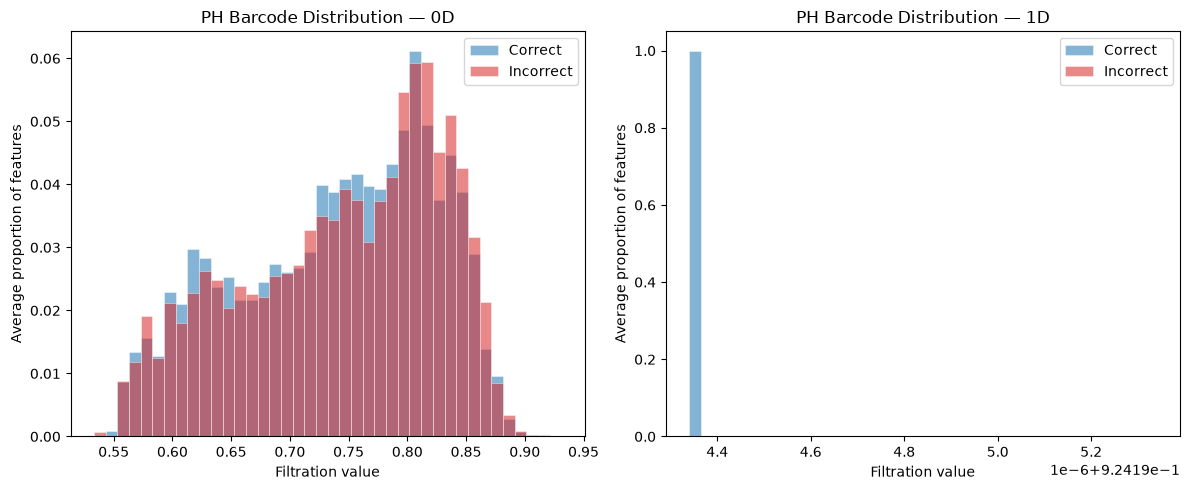

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['mmlu_moral', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_moral.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+----------------------+------------------------+------------------------+------------------------+----------------------+-----------------------+
|       label        |       num_feat       |        max_feat        | max_feat_minus_second  |       mean_feat        |     betti_curve      |  persistence_entropy  |
+--------------------+----------------------+------------------------+------------------------+------------------------+----------------------+-----------------------+
|    correct_0dim    |        117.36        |   0.916131591796875    |    0.0156787109375     |   0.7464570591739833   |       94.8554        |   4.757299722225754   |
| correct_0dim_stdv  |   0.75190263715296   | 0.0006644059266121181  | 0.0008121613950689526  | 0.0002627224245733172  |  0.575872

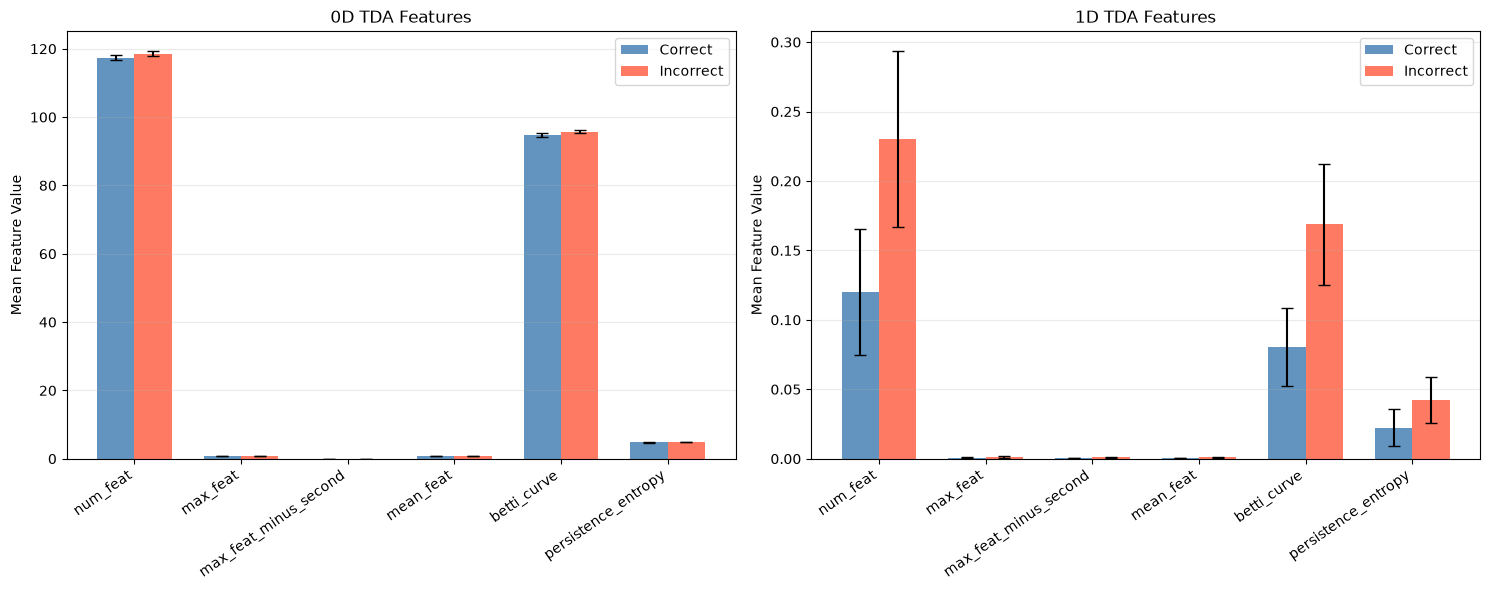

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 6
Incorrect samples 1 dim: 12
Filtration range 0 dim: 0.56860352 0.93481445
Filtration range 1 dim: 0.93292236 0.9727478


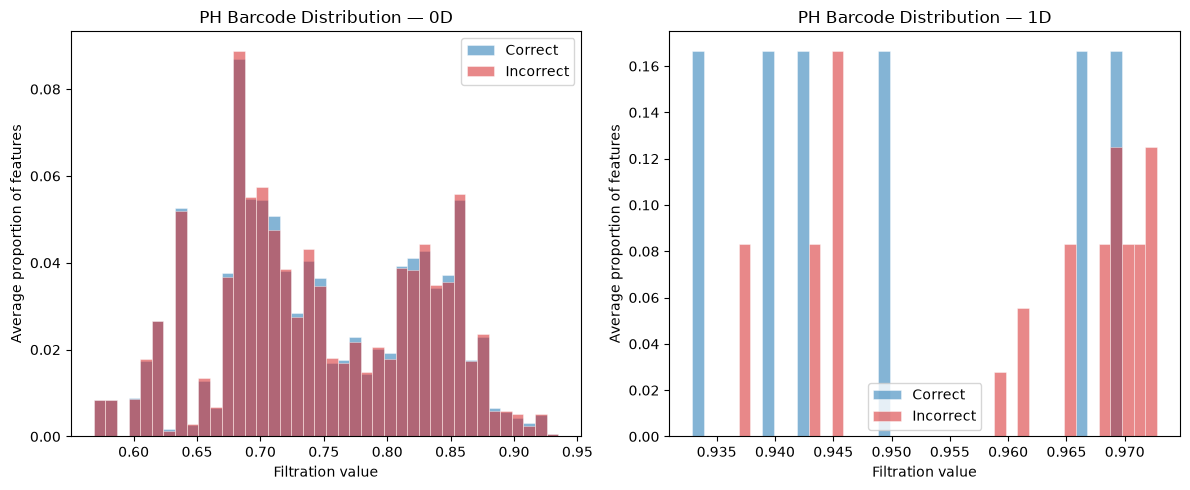

model:  ['Mistral 7B v0.3', 'mistralai/Mistral-7B-v0.3', 'mistral']
dataset:  ['mmlu_psych', '~/TDA_RI/TDA_reason-interpret/datasets/mmlu_psych.csv']
Sampling 100 correct and 100 incorrect examples
+--------------------+----------------------+-------------------------+------------------------+-------------------------+-------------------------+------------------------+
|       label        |       num_feat       |         max_feat        | max_feat_minus_second  |        mean_feat        |       betti_curve       |  persistence_entropy   |
+--------------------+----------------------+-------------------------+------------------------+-------------------------+-------------------------+------------------------+
|    correct_0dim    |        82.75         |    0.887901611328125    |   0.0073211669921875   |    0.7470364209423139   |          69.027         |   4.348876596331737    |
| correct_0dim_stdv  |  3.059424089199756   |   0.001510518582811014  | 0.0006088907504445932  |  0.001856

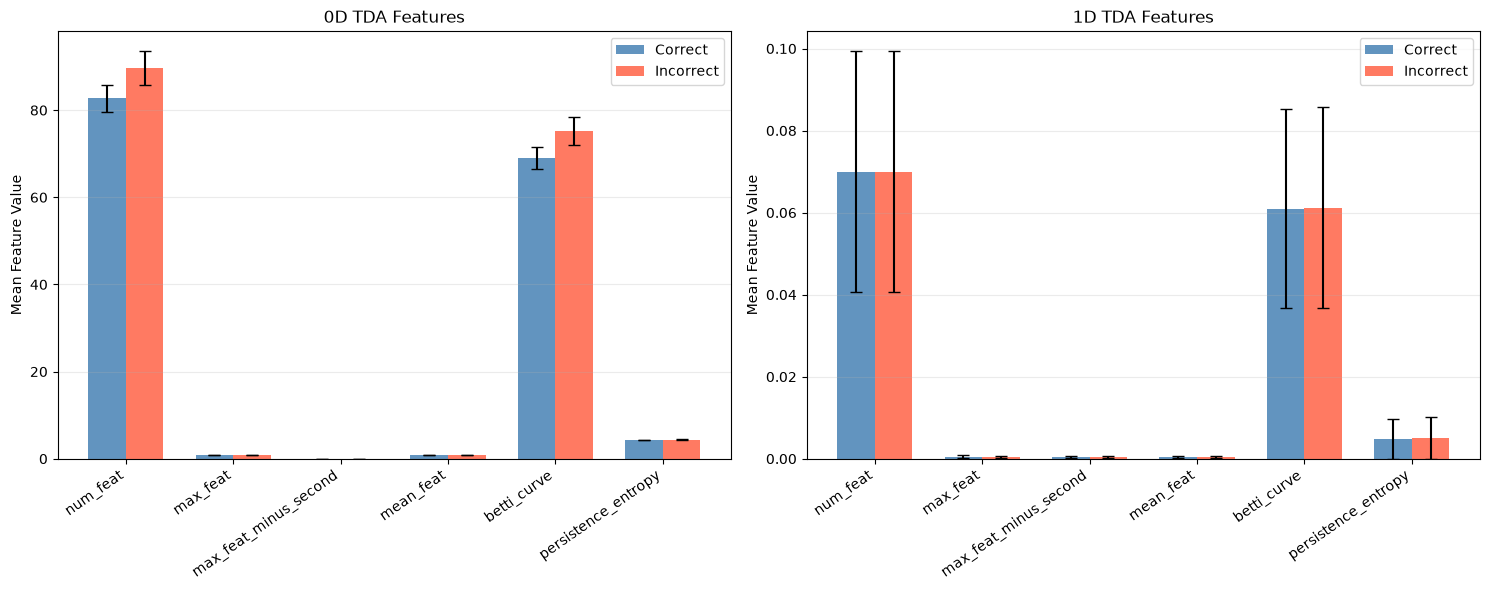

Sampling 100 correct and 100 incorrect examples
Correct samples 0 dim: 100
Incorrect samples 0 dim: 100
Correct samples 1 dim: 7
Incorrect samples 1 dim: 6
Filtration range 0 dim: 0.52905273 0.93670654
Filtration range 1 dim: 0.92211914 0.98539734


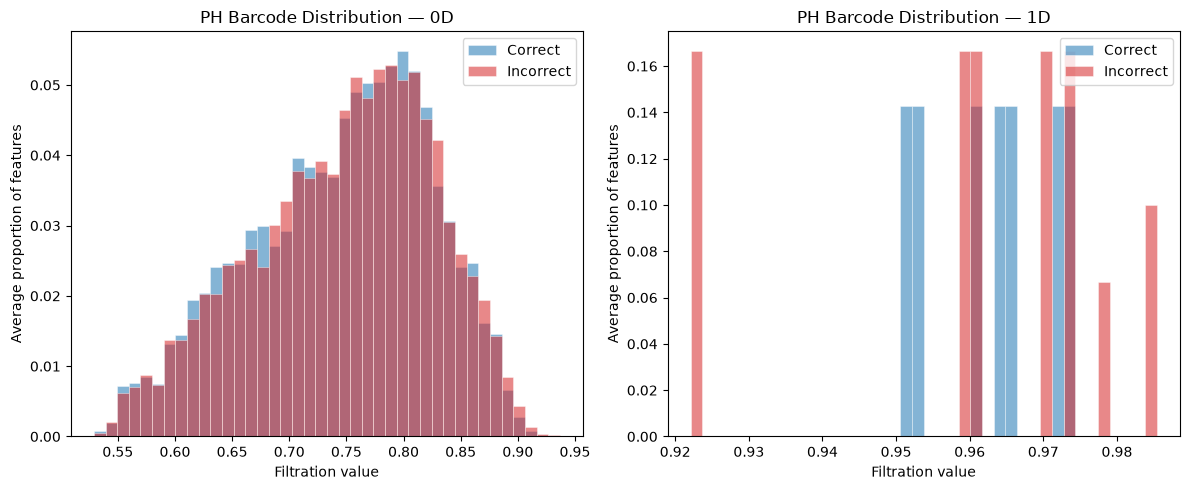

In [6]:
for model in models:
    for dataset in datasets:
        print("model: ", model)
        print("dataset: ", dataset)
        topo.analyze_feats(model, dataset, False)
        topo.plot_barcode(model, dataset)

In [7]:
# get heatmap!
ling.make_heatmap(datasets[0], models[0], linguistic_labels[0], tda_labels[0])

AttributeError: module 'analysis_functions' has no attribute 'get_ling_feat'

In [ ]:
# test pval corr matrix
# choose model and dataset
model_index2 = [1, 2, 5, 6]
data_index2 = [1, 1, 4, 4]
# model_id =  models[8]
# dataset = datasets[3]

# choose linguistic labels :0
tda_label2 = tda_labels[0]

# get heatmap!
for i in range(0,4):
    cor_heat = make_heatmap(datasets[data_index2[i]], models[model_index2[i]], linguistic_labels[0], tda_label, extra_label = "_appendix", save = True)
    p_heat = make_pval_heatmap(datasets[data_index2[i]], models[model_index2[i]], linguistic_labels[0], tda_label, extra_label = "_appendix", save = True)


In [ ]:
per_sig, avg_pval = make_pval_heatmap(datasets[0], models[0])

# rows = ['Llama'] #, 'Qwen 3','RoBERTa', 'Electra']
# columns = ['flores-200'] #, 'OPUS-100']

# df_per = pd.DataFrame(per_sig)
# df_avg = pd.DataFrame(avg_pval)

# df_per.columns = columns
# df_avg.columns = columns

# df_per = df_per.mean(axis=1)
# df_avg = df_avg.mean(axis=1)

# print(df_per)
# print(df_avg)

In [ ]:
# code for table with avg number of words and sentences per data for appendix
for dataset in datasets:
    name, data_csv, eng_label, _ = data_label(dataset)
    df_dataset = pd.read_csv(data_csv)

    # count sentences and words
    df_dataset["sentence_count"] = df_dataset[f"{eng_label}"].apply(lambda x: len(sent_tokenize(x)))
    df_dataset["word_count"] = df_dataset[f"{eng_label}"].apply(lambda x: len(word_tokenize(x)))

    # compute averages
    avg_words = df_dataset["word_count"].mean()
    avg_sentences = df_dataset["sentence_count"].mean()

    print(name, ": ")
    summary_table = pd.DataFrame({
        "Metric": ["Average Words", "Average Sentences"],
        "Value": [avg_words, avg_sentences]
    })

    print(summary_table)